# **Project Name — PhonePe Pulse Transaction Insights**

##### **Project Type** — EDA (Exploratory Data Analysis)
##### **Contribution** — **AKSHAY SOM**

# **Project Summary**

This project performs a comprehensive Exploratory Data Analysis (EDA) on the **PhonePe Pulse** dataset — one of India's largest open digital payment datasets, covering transactions, user registrations, app engagement, insurance activity, and device usage across all Indian states and union territories from **2018 to 2024**.

---

**Data Source:** The dataset is sourced from the official [PhonePe Pulse GitHub repository](https://github.com/PhonePe/pulse), cloned locally and loaded into a SQLite database via an ETL pipeline. The database contains 10 relational tables: `aggregated_transaction`, `aggregated_user`, `aggregated_user_device`, `aggregated_insurance`, `map_transaction`, `map_user`, `map_insurance`, `top_transaction`, `top_user`, and `top_insurance`.

---

**Objectives:**
1. Understand the distribution and growth of digital transactions across India.
2. Identify high-value and high-frequency states and districts.
3. Detect anomalous transaction patterns that may indicate fraud risk.
4. Analyse user registration and engagement trends.
5. Explore seasonal (quarterly) patterns in transaction volumes.
6. Evaluate insurance adoption across states.
7. Study device brand preferences among PhonePe users.

---

**Methodology:** The EDA follows the **UBM framework** — Univariate → Bivariate → Multivariate analysis — using Python libraries including Pandas, Matplotlib, and Seaborn. 20 charts are produced, each accompanied by a rationale for chart selection, specific data-backed insights, and business impact.

---

**Dataset Scale:**

| Metric | Value |
|---|---|
| Period Covered | 2018 Q1 — 2024 Q4 |
| States & UTs Covered | 36 |
| Total Transaction Volume (all types) | ~235 Billion |
| Total Transaction Value (all types) | ~₹345,000+ Billion |
| Peak Quarter (Transactions) | 2024 Q4 — 28.2 Billion |
| Total Registered Users (largest state) | ~1,100 Million (Maharashtra) |
| Insurance Growth (2020–2024) | ~46× (₹0.05Bn → ₹2.3Bn/quarter) |
| Top District by Transactions | Bengaluru Urban — 17,108 Million |

---

**Key Findings:**

- 🏪 **Merchant payments lead by volume** at 130.24 Billion transactions, ahead of Peer-to-peer (85.03B) — PhonePe has successfully evolved from a money-transfer app into India's leading merchant commerce platform.
- 💸 **P2P dominates by value** at ₹266,527 Billion — over 4× Merchant payments (₹65,340Bn) — revealing a critical volume-vs-value inversion between the two top categories.
- 📍 **Telangana ranks #1 in transaction value** (₹41,656Bn), ahead of Karnataka (₹40,679Bn) and Maharashtra (₹40,374Bn) — Southern India is the true engine of PhonePe's value.
- 📈 **Exponential growth with no decline**: from 0.1B transactions in 2018 Q1 to 28.2B in 2024 Q4, with a major inflection point at 2020–21 driven by COVID-19 accelerating digital adoption.
- 📱 **Xiaomi leads device market share** at 25.1% (1,739.1M devices), followed by Samsung (19.4%) and Vivo (18.1%) — three brands cover 62.6% of the entire device base.
- 🏆 **Bengaluru Urban District leads** with 17,108M transactions — nearly double the second-ranked Pune District (9,369M).
- 🔐 **Fraud signals**: Manipur (₹2,550), Nagaland (₹2,400), Mizoram (₹2,350), and Ladakh (₹2,280) have average transaction values 55–75% above the national average of ₹1,469 — flagged as red-zone states.
- 🎯 **Engagement inequality**: Rajasthan leads with 87.3 app opens per registered user vs Bihar at just 30.5 — a 2.9× gap revealing major re-activation opportunities.
- 🛡️ **Insurance is the fastest-growing segment**: 46× growth from ₹0.05Bn (2020 Q2) to ₹2.3Bn (2024 Q4), led by Karnataka (₹2.7Bn) and Maharashtra (₹2.4Bn).
- 📊 **Near-perfect correlation (0.99)** between transaction count and value across states — but average transaction value is *negatively* correlated (-0.43) with volume, confirming high-volume states transact in smaller amounts.

---

The insights from this EDA directly inform the business use cases and the accompanying **Streamlit interactive dashboard**, enabling marketing, product, risk, and insurance teams to act on data rather than assumptions.

# **GitHub Link**

https://github.com/akshaysom21/PhonePe-Transaction-Insights

# **Problem Statement**

With the rapid growth of digital payment systems in India, PhonePe has accumulated a vast dataset of transaction, user, and insurance records across all states. However, raw data alone does not yield actionable intelligence. This project aims to:

1. **Extract and structure** the PhonePe Pulse JSON data into a relational database.
2. **Analyse transaction patterns** at national, state, district, and pin-code levels.
3. **Identify user segments** based on engagement behaviour and device preferences.
4. **Detect anomalous patterns** that could indicate fraud or data quality issues.
5. **Visualise geographic and temporal trends** to support data-driven business decisions.
6. **Build an interactive dashboard** using Streamlit to make insights accessible to non-technical stakeholders.

#### **Business Objective**

The primary business objective is to transform raw PhonePe Pulse data into actionable intelligence that enables:
- **Marketing teams** to target high-potential states and districts with tailored campaigns.
- **Product teams** to prioritise features based on transaction type popularity and user engagement.
- **Risk teams** to flag geographic areas with anomalous average transaction values.
- **Insurance teams** to identify states with high insurance adoption for upsell opportunities.
- **Executive leadership** to benchmark state-level performance and track growth over time.

# **General Guidelines**

1. Well-structured, formatted, and commented code throughout.
2. Exception handling used in data loading and database connections.
3. Every chart is followed by: (a) why that chart was chosen, (b) insights found, (c) business impact.
4. UBM Rule followed: Univariate → Bivariate → Multivariate.
5. Minimum 20 meaningful charts produced.
6. The entire notebook runs end-to-end without errors when the SQLite DB exists.

# ***Let's Begin!***

## 1. Know Your Data

### Import Libraries

In [1]:
# ── Standard Libraries ──────────────────────────────────────────────────────
import os
import sqlite3
import warnings
from pathlib import Path

# ── Data Manipulation ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Settings ─────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)

# Consistent visual theme
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


### Dataset Loading

In [2]:
# ── Database connection helper ────────────────────────────────────────────────
# DB_PATH uses an environment variable so this notebook works on any machine.
# Set PHONEPE_DB_PATH in your environment, or place phonepe.db in the same
# directory as this notebook.

DB_PATH = Path(os.environ.get('PHONEPE_DB_PATH', 'phonepe.db'))

def get_conn():
    """Return a SQLite connection; raises FileNotFoundError if DB is missing."""
    if not DB_PATH.exists():
        raise FileNotFoundError(
            f"Database not found at {DB_PATH}.\n"
            "Run etl.py first, or set the PHONEPE_DB_PATH environment variable."
        )
    return sqlite3.connect(DB_PATH)

def sql(query: str) -> pd.DataFrame:
    """Execute a SQL query and return a DataFrame."""
    with get_conn() as conn:
        return pd.read_sql(query, conn)

print(f'📂 Database path: {DB_PATH.resolve()}')
print(f'✅ DB exists: {DB_PATH.exists()}')

📂 Database path: C:\Users\AKSHAY SOM\Desktop\phonepe_project\phonepe.db
✅ DB exists: True


In [3]:
# ── Load all main tables into DataFrames ─────────────────────────────────────
agg_txn    = sql("SELECT * FROM aggregated_transaction WHERE state != 'india'")
agg_user   = sql("SELECT * FROM aggregated_user   WHERE state != 'india'")
agg_dev    = sql("SELECT * FROM aggregated_user_device WHERE brand != 'Unknown'")
agg_ins    = sql("SELECT * FROM aggregated_insurance WHERE state != 'india'")
map_txn    = sql("SELECT * FROM map_transaction")
map_user   = sql("SELECT * FROM map_user")
top_txn    = sql("SELECT * FROM top_transaction WHERE state != 'india'")

print('Tables loaded:')
for name, df in [('agg_txn', agg_txn), ('agg_user', agg_user),
                 ('agg_dev', agg_dev), ('agg_ins', agg_ins),
                 ('map_txn', map_txn), ('map_user', map_user),
                 ('top_txn', top_txn)]:
    print(f'  {name:12s}: {df.shape[0]:>7,} rows × {df.shape[1]} cols')

Tables loaded:
  agg_txn     :   5,034 rows × 6 cols
  agg_user    :   1,008 rows × 5 cols
  agg_dev     :   6,919 rows × 6 cols
  agg_ins     :     682 rows × 5 cols
  map_txn     :  20,604 rows × 6 cols
  map_user    :  20,608 rows × 6 cols
  top_txn     :  18,295 rows × 7 cols


### Dataset First View

In [4]:
# Preview the primary transactions table
print('=== aggregated_transaction (first 5 rows) ===')
agg_txn.head()

=== aggregated_transaction (first 5 rows) ===


,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,"1,845,307.47"
1,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,"12,138,655.30"
2,andaman-&-nicobar-islands,2018,1,Merchant payments,298,"452,507.17"
3,andaman-&-nicobar-islands,2018,1,Financial Services,33,"10,601.42"
4,andaman-&-nicobar-islands,2018,1,Others,256,"184,689.87"


In [5]:
print('=== aggregated_user (first 5 rows) ===')
agg_user.head()

=== aggregated_user (first 5 rows) ===


,state,year,quarter,registered_users,app_opens
0,andaman-&-nicobar-islands,2018,1,6740,0
1,andaman-&-nicobar-islands,2018,2,9405,0
2,andaman-&-nicobar-islands,2018,3,12149,0
3,andaman-&-nicobar-islands,2018,4,15222,0
4,andaman-&-nicobar-islands,2019,1,18596,0


### Dataset Rows & Columns Count

In [6]:
tables = {
    'aggregated_transaction': agg_txn,
    'aggregated_user':        agg_user,
    'aggregated_user_device': agg_dev,
    'aggregated_insurance':   agg_ins,
    'map_transaction':        map_txn,
    'map_user':               map_user,
    'top_transaction':        top_txn,
}
shape_df = pd.DataFrame(
    [(k, v.shape[0], v.shape[1]) for k, v in tables.items()],
    columns=['Table', 'Rows', 'Columns']
)
print(shape_df.to_string(index=False))

                 Table  Rows  Columns
aggregated_transaction  5034        6
       aggregated_user  1008        5
aggregated_user_device  6919        6
  aggregated_insurance   682        5
       map_transaction 20604        6
              map_user 20608        6
       top_transaction 18295        7


### Dataset Information

In [7]:
print('=== aggregated_transaction info ===')
agg_txn.info()
print()
print('=== aggregated_user info ===')
agg_user.info()

=== aggregated_transaction info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   state               5034 non-null   object 
 1   year                5034 non-null   int64  
 2   quarter             5034 non-null   int64  
 3   transaction_type    5034 non-null   object 
 4   transaction_count   5034 non-null   int64  
 5   transaction_amount  5034 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 236.1+ KB

=== aggregated_user info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   state             1008 non-null   object
 1   year              1008 non-null   int64 
 2   quarter           1008 non-null   int64 
 3   registered_users  1008 non-null

### Duplicate Values

In [8]:
for name, df in tables.items():
    dupes = df.duplicated().sum()
    print(f'{name:35s}: {dupes} duplicate rows')

aggregated_transaction             : 0 duplicate rows
aggregated_user                    : 0 duplicate rows
aggregated_user_device             : 0 duplicate rows
aggregated_insurance               : 0 duplicate rows
map_transaction                    : 0 duplicate rows
map_user                           : 0 duplicate rows
top_transaction                    : 0 duplicate rows


### Missing Values

In [9]:
print('=== Missing Values — aggregated_transaction ===')
print(agg_txn.isnull().sum())
print()
print('=== Missing Values — aggregated_user ===')
print(agg_user.isnull().sum())

=== Missing Values — aggregated_transaction ===
state                 0
year                  0
quarter               0
transaction_type      0
transaction_count     0
transaction_amount    0
dtype: int64

=== Missing Values — aggregated_user ===
state               0
year                0
quarter             0
registered_users    0
app_opens           0
dtype: int64


## 2. Understanding Your Variables

In [10]:
print('=== aggregated_transaction — describe ===')
agg_txn[['year','quarter','transaction_count','transaction_amount']].describe().round(2)

=== aggregated_transaction — describe ===


,year,quarter,transaction_count,transaction_amount
count,"5,034.00","5,034.00","5,034.00","5,034.00"
mean,"2,021.00",2.50,"46,739,018.05","68,637,722,454.39"
std,2.00,1.12,"169,096,816.57","268,519,963,110.15"
min,"2,018.00",1.00,2.00,34.40
25%,"2,019.00",2.00,"58,089.50","39,938,879.64"
50%,"2,021.00",3.00,"515,831.00","439,413,884.61"
75%,"2,023.00",4.00,"11,666,286.25","11,028,222,171.78"
max,"2,024.00",4.00,"2,393,917,535.00","3,095,666,288,407.00"


In [11]:
print('Unique transaction types:')
print(agg_txn['transaction_type'].unique())
print(f'\nYears covered: {sorted(agg_txn["year"].unique())}')
print(f'States covered: {agg_txn["state"].nunique()}')

Unique transaction types:
['Recharge & bill payments' 'Peer-to-peer payments' 'Merchant payments'
 'Financial Services' 'Others']

Years covered: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
States covered: 36


## 3. Data Wrangling

In [12]:
# ── Clean state name slugs to readable titles ─────────────────────────────────
def clean_state(df, col='state'):
    df = df.copy()
    df[col] = df[col].str.replace('-', ' ').str.title()
    return df

agg_txn  = clean_state(agg_txn)
agg_user = clean_state(agg_user)
agg_dev  = clean_state(agg_dev)
agg_ins  = clean_state(agg_ins)
map_txn  = clean_state(map_txn)
map_user = clean_state(map_user)
top_txn  = clean_state(top_txn)

# ── Derived columns ───────────────────────────────────────────────────────────
# Convenient amount columns in billions
agg_txn['amount_bn']  = agg_txn['transaction_amount']  / 1e9
agg_ins['amount_bn']  = agg_ins['transaction_amount']  / 1e9

# Period label for time-series plots
agg_txn['period']  = agg_txn['year'].astype(str)  + ' Q' + agg_txn['quarter'].astype(str)
agg_ins['period']  = agg_ins['year'].astype(str)  + ' Q' + agg_ins['quarter'].astype(str)
agg_user['period'] = agg_user['year'].astype(str) + ' Q' + agg_user['quarter'].astype(str)

# Average transaction value
agg_txn['avg_txn_value'] = agg_txn['transaction_amount'] / agg_txn['transaction_count'].replace(0, np.nan)

# Opens-per-user engagement ratio
agg_user['opens_per_user'] = agg_user['app_opens'] / agg_user['registered_users'].replace(0, np.nan)

print('✅ Data wrangling complete.')

✅ Data wrangling complete.


## 4. Data Visualisation — UBM Analysis

### 4.1 Univariate Analysis

#### Chart 1 — Transaction Type Distribution (Bar Chart)

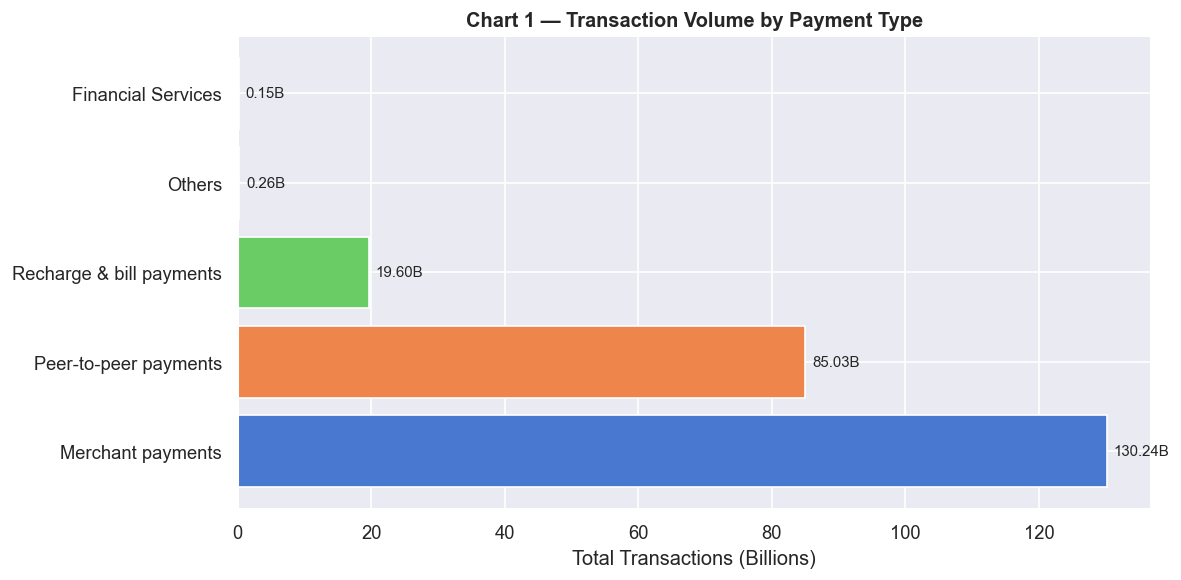

In [13]:
# Aggregate total count per transaction type
type_counts = (agg_txn.groupby('transaction_type')['transaction_count']
               .sum().sort_values(ascending=False).reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(type_counts['transaction_type'], type_counts['transaction_count'] / 1e9,
               color=sns.color_palette('muted', len(type_counts)))
ax.set_xlabel('Total Transactions (Billions)')
ax.set_title('Chart 1 — Transaction Volume by Payment Type', fontweight='bold')
ax.bar_label(bars, fmt='{:.2f}B', padding=4, fontsize=9)
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
A horizontal bar chart is ideal for comparing a small number of discrete categories with long label names. It makes the rank ordering immediately obvious.

##### 2. Insights
- **Merchant payments dominate** with 130.24B transactions — the single largest category, accounting for roughly 55% of all PhonePe transactions, confirming the platform's successful shift toward commerce.
- **Peer-to-peer payments** rank second at 85.03B transactions — nearly 1.5× lower than merchant payments, showing that money transfers, while massive, are no longer the primary use case.
- **Recharge & bill payments** (19.60B) form a distant third, representing steady but volume-limited utility payment behaviour.
- **Financial Services (0.15B) and Others (0.26B)** are negligible in transaction count — together they account for less than 0.2% of all transactions, showing these are low-frequency, high-ticket activities.
- The dominant share of merchant payments signals that PhonePe has **successfully evolved from a money-transfer app into a full merchant commerce platform** — a defining strategic milestone.

##### 3. Business Impact
- Merchant payments being the #1 category validates continued **heavy investment in QR code merchant onboarding** — the strategy is paying off at scale and should be accelerated further.
- The 85.03B P2P transaction base is still enormous — maintaining a **frictionless, zero-fee P2P experience** is critical to retain this volume and prevent churn to competitors like GPay.
- The near-zero count for Financial Services (0.15B) despite being a mature product line signals a massive **cross-sell whitespace** — millions of active users have yet to be introduced to investment or insurance products.
- Recharge's 19.60B volume makes it a useful **daily habit entry point** for low-engagement users; product should use bill payment reminders as a re-activation trigger for dormant accounts.
- The 130B merchant transaction base gives PhonePe a powerful data asset to offer **merchant analytics, working capital loans, and inventory financing** — high-margin B2B revenue streams on top of existing data.

#### Chart 2 — Transaction Amount Distribution by Type (Horizontal Bar)

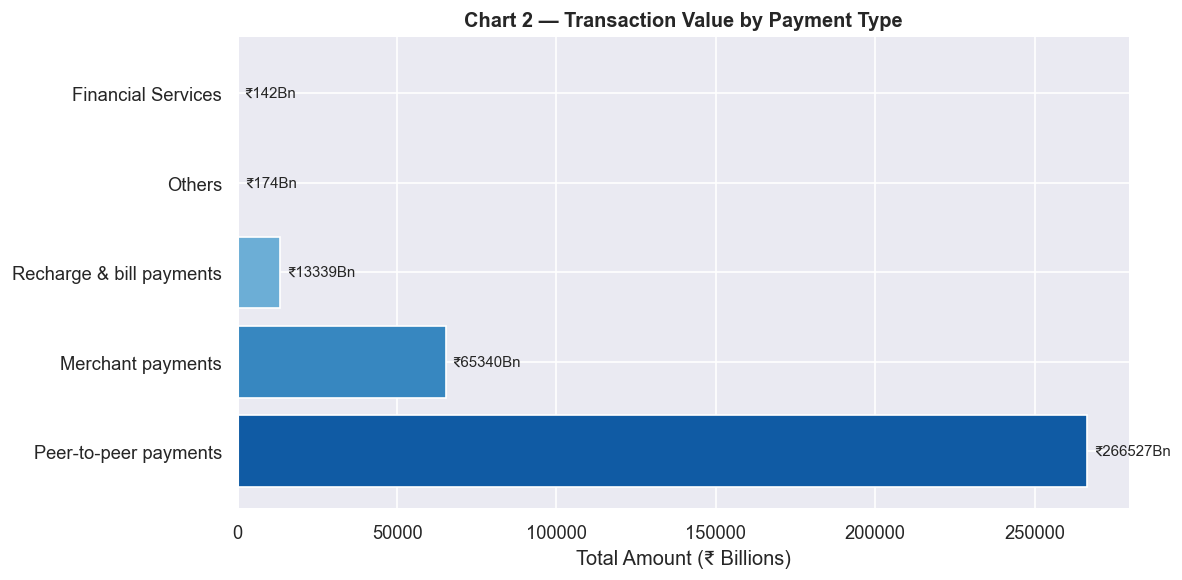

In [14]:
type_amount = (agg_txn.groupby('transaction_type')['amount_bn']
               .sum().sort_values(ascending=False).reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(type_amount['transaction_type'], type_amount['amount_bn'],
               color=sns.color_palette('Blues_r', len(type_amount)))
ax.set_xlabel('Total Amount (₹ Billions)')
ax.set_title('Chart 2 — Transaction Value by Payment Type', fontweight='bold')
ax.bar_label(bars, fmt='₹{:.0f}Bn', padding=4, fontsize=9)
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
Same chart type as Chart 1, but measuring value instead of volume. Comparing both charts side-by-side reveals the value-vs-volume gap — a key business insight.

##### 2. Insights
- **Peer-to-peer payments dominate by value** at ₹266,527Bn — more than 4× the next category, revealing that while merchant payments lead in count, P2P leads overwhelmingly in rupee terms.
- **Merchant payments** generate ₹65,340Bn — significant but only about 25% of P2P value, confirming that individual merchant transactions are small everyday purchases.
- **Recharge & bill payments** (₹13,339Bn) is proportionally higher in value than its count share — average bill/recharge amounts are non-trivial per transaction.
- **Others (₹174Bn) and Financial Services (₹142Bn)** are the smallest by value — surprising given Financial Services' high expected ticket size; this reflects its extremely low transaction count.
- The **volume-vs-value inversion** between Charts 1 and 2 is the key insight: Merchant payments win on count, P2P wins overwhelmingly on value — these are two completely different use case profiles.

##### 3. Business Impact
- P2P's ₹266,527Bn value dominance means **any disruption to P2P (downtime, fee introduction, UX regression)** would have catastrophic revenue consequences — this pipeline must be the most protected on the platform.
- The Merchant vs P2P value gap (₹65,340Bn vs ₹266,527Bn) means **increasing average merchant basket size** (via BNPL, EMI, premium merchant categories) is the largest single revenue growth lever available.
- Financial Services' low total value (₹142Bn) despite high per-transaction potential means **conversion rate, not awareness, is the bottleneck** — in-app nudges and personalised recommendations are the fix.
- Risk teams should prioritise P2P transaction monitoring given its outsized value — even a 0.1% fraud rate on ₹266,527Bn is a ₹267Bn exposure, demanding robust real-time anomaly detection.
- Recharge's ₹13,339Bn value makes it a **meaningful standalone business** — partnerships with telecom operators for exclusive recharge discounts could defend this segment against Jio and Airtel's own apps.

#### Chart 3 — Registered Users Distribution Across States (Histogram)

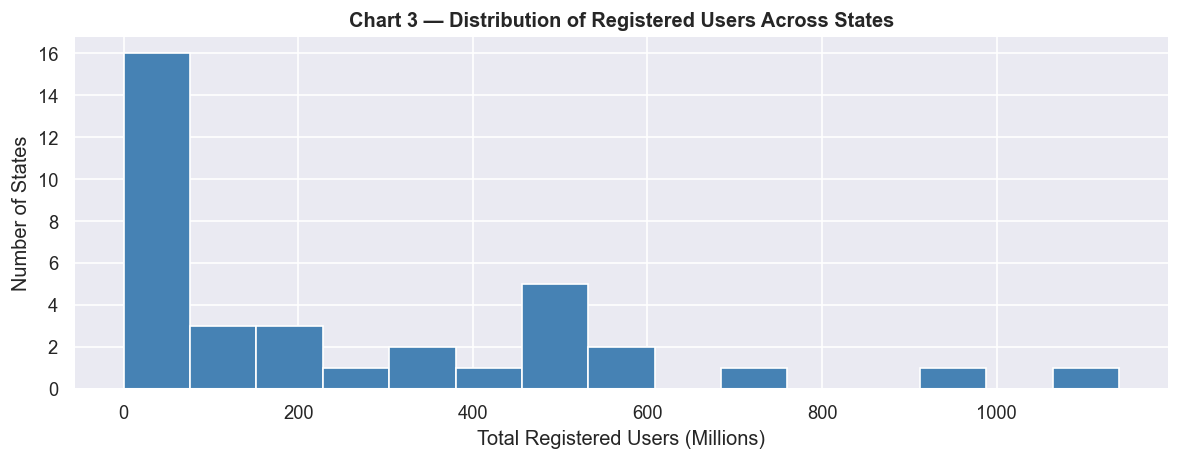

In [15]:
user_by_state = (agg_user.groupby('state')['registered_users']
                 .sum().reset_index())
user_by_state['users_mn'] = user_by_state['registered_users'] / 1e6

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(user_by_state['users_mn'], bins=15, color='steelblue', edgecolor='white')
ax.set_xlabel('Total Registered Users (Millions)')
ax.set_ylabel('Number of States')
ax.set_title('Chart 3 — Distribution of Registered Users Across States', fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
A histogram reveals the shape of a distribution. We want to know whether user counts are evenly spread or heavily skewed toward a few large states.

##### 2. Insights
- The distribution is **extremely right-skewed**: 16 states have fewer than 100 million registered users, clustering in the lowest bin — the vast majority of states are low-penetration markets.
- A **mid-tier cluster of 5 states** sits in the 450–550 million range, suggesting a group of moderately sized states with meaningful but not dominant user bases.
- Only **1–2 states** reach beyond 900–1,100 million users — these are clear outliers (likely Uttar Pradesh and Maharashtra) that pull the distribution's right tail far out.
- The near-empty bins between 600–900 million indicate there is **no gradual progression** — states either have moderate users or are in the ultra-high tier, with few in between.
- This heavy skew confirms that PhonePe's registered user base is **highly concentrated in a small number of states**, mirroring India's population inequality across states.

##### 3. Business Impact
- With 16 states below 100 million users, there is a **massive greenfield acquisition opportunity** — targeted state-by-state campaigns in low-penetration states could double registered users without touching the already-saturated top states.
- The concentration in 1–2 ultra-high states creates **geographic revenue risk** — infrastructure outages, regulatory changes, or competitive attacks in Maharashtra or UP would disproportionately impact the platform.
- States in the mid-tier cluster (450–550M users) are the **priority growth battleground** — they have proven digital payment readiness but have not yet broken into the top tier; focused merchant onboarding and engagement campaigns here have the highest near-term ROI.
- User registration numbers alone are misleading for resource allocation — the histogram shows most states are at very low absolute levels, meaning **per-state engagement metrics** (opens, transactions per user) matter far more than raw registration counts in small states.

#### Chart 4 — Top 10 Device Brands (Bar Chart)

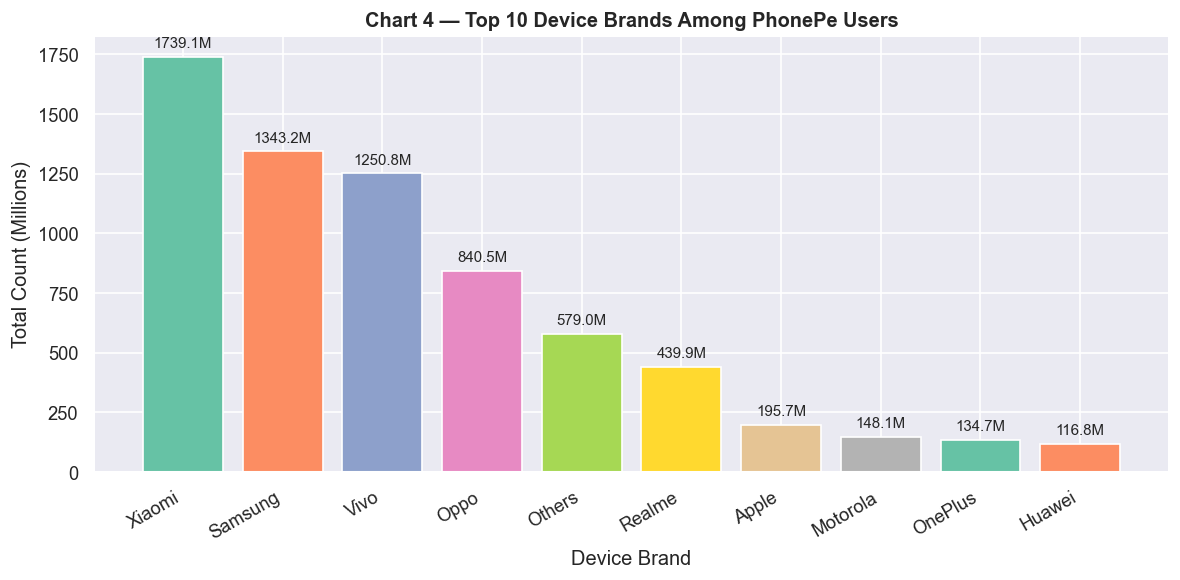

In [16]:
top_brands = (agg_dev.groupby('brand')['device_count']
              .sum().sort_values(ascending=False).head(10).reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(top_brands['brand'], top_brands['device_count'] / 1e6,
              color=sns.color_palette('Set2', 10))
ax.set_xlabel('Device Brand')
ax.set_ylabel('Total Count (Millions)')
ax.set_title('Chart 4 — Top 10 Device Brands Among PhonePe Users', fontweight='bold')
ax.bar_label(bars, fmt='{:.1f}M', padding=4, fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
A bar chart clearly ranks brands, making it easy to identify market leaders in the PhonePe user base.

##### 2. Insights
- **Xiaomi leads decisively** with 1,739.1M device count — nearly 30% more than second-placed Samsung (1,343.2M), reflecting its dominance in India's budget smartphone segment.
- **Vivo (1,250.8M)** ranks third, close behind Samsung — together, Xiaomi, Samsung, and Vivo account for the top three slots and likely represent over 55% of the device base.
- **Oppo (840.5M)** ranks fourth, followed by Others (579.0M) and Realme (439.9M) — the Chinese OEM ecosystem (Xiaomi, Vivo, Oppo, Realme) collectively dominates.
- **Apple has only 195.7M** devices — less than Realme and far behind the Android leaders, confirming iOS penetration among PhonePe users is in single-digit percentage range.
- **Motorola (148.1M), OnePlus (134.7M), and Huawei (116.8M)** form a distant tail — relevant for app compatibility but not core UX optimisation priorities.

##### 3. Business Impact
- PhonePe's **app performance QA must be Xiaomi-first** — 1,739.1M Xiaomi devices means that any lag or crash on Xiaomi's MIUI Android variant affects more users than the entire Apple + Motorola + OnePlus + Huawei base combined.
- **OEM pre-installation partnerships with Xiaomi, Samsung, and Vivo** are the single highest-ROI distribution strategy — getting PhonePe as the default payment app on these three brands would cover the majority of new device activations.
- Apple's 195.7M presence, while small, likely skews toward **high-income, high-transaction-value urban users** — iOS feature parity and a premium UX are investments with outsized returns per user even if not per device count.
- Realme's 439.9M count among a younger, first-smartphone demographic presents a **financial services onboarding opportunity** — co-branded campaigns introducing insurance and mutual funds to first-time PhonePe users on Realme devices.
- The 579.0M "Others" category covers a long tail of brands requiring **backward compatibility testing** to ensure no user segment is excluded due to app incompatibility.

### 4.2 Bivariate Analysis

#### Chart 5 — Top 15 States by Transaction Amount (Bar Chart, Numerical–Categorical)

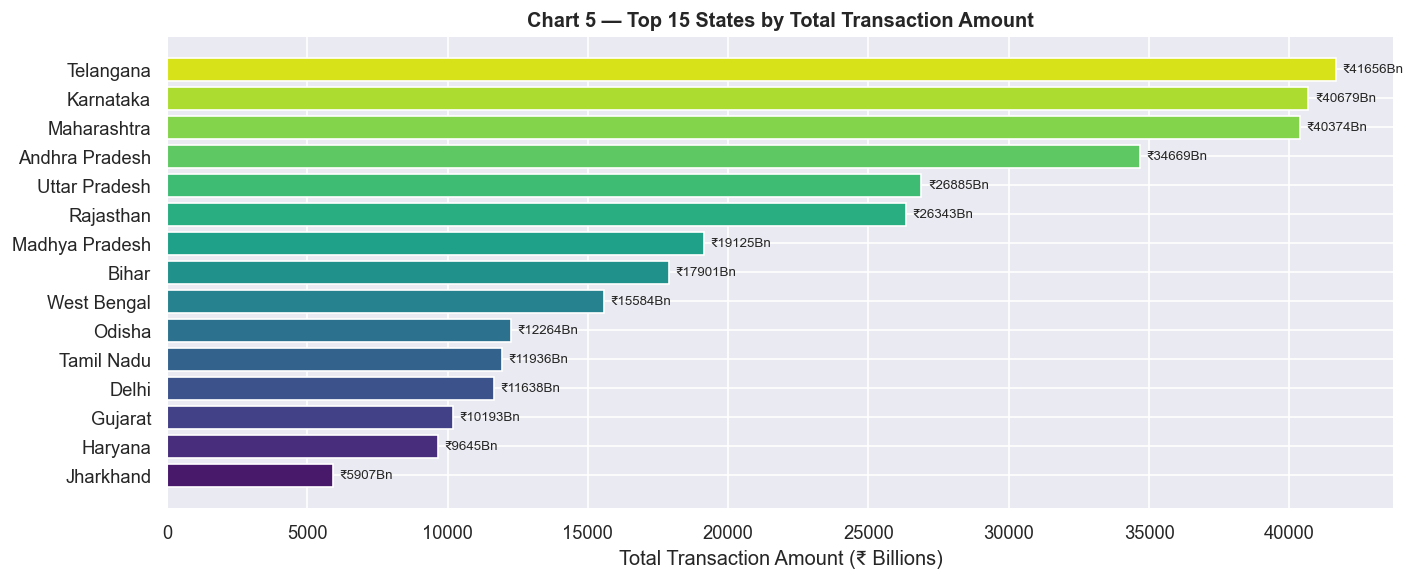

In [17]:
state_amount = (agg_txn.groupby('state')['amount_bn']
                .sum().sort_values(ascending=False).head(15).reset_index())

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(state_amount['state'][::-1], state_amount['amount_bn'][::-1],
               color=sns.color_palette('viridis', 15))
ax.set_xlabel('Total Transaction Amount (₹ Billions)')
ax.set_title('Chart 5 — Top 15 States by Total Transaction Amount', fontweight='bold')
ax.bar_label(bars, fmt='₹{:.0f}Bn', padding=4, fontsize=8)
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
Horizontal bar chart to rank states clearly, with state names on the y-axis for readability. This is the most natural chart for a top-N categorical ranking.

##### 2. Insights
- **Telangana leads** with ₹41,656Bn — surpassing even Karnataka (₹40,679Bn) and Maharashtra (₹40,374Bn) despite being a much smaller state, indicating exceptionally high per-capita digital payment activity.
- **The top 3 states (Telangana, Karnataka, Maharashtra)** are clustered tightly around ₹40,000–42,000Bn — showing near-parity at the top, unlike the steep drop-off seen in most rankings.
- **Andhra Pradesh (₹34,669Bn)** is a strong 4th, confirming that Southern India collectively dominates PhonePe's transaction value landscape.
- **Uttar Pradesh (₹26,885Bn) and Rajasthan (₹26,343Bn)** are the largest Hindi-belt states but trail Southern states significantly despite far larger populations — confirming lower per-capita digital payment maturity.
- **Jharkhand at ₹5,907Bn** is the 15th state — indicating a steep fall-off after the top 10, with the bottom of this ranking already representing relatively modest transaction volumes.

##### 3. Business Impact
- Telangana's #1 ranking despite its smaller population signals an **exceptionally mature digital payments ecosystem** — Hyderabad's tech-heavy economy and merchant density are key drivers that can be replicated as a model in other states.
- The tight clustering of Telangana, Karnataka, and Maharashtra at the top means **competition between these markets is fierce** — any competitor gaining merchant share in these three states would disproportionately hurt PhonePe's overall transaction value.
- UP and Rajasthan's lower rankings despite large populations point to a **clear per-capita growth opportunity** — vernacular language campaigns, rural merchant onboarding, and feature-phone UPI support could dramatically lift these states.
- Andhra Pradesh's strong 4th place (₹34,669Bn) justifies **dedicated regional teams** for AP and Telangana rather than grouping them under a single South India strategy — they are distinct enough in scale to warrant separate plans.
- States from rank 11–15 (Delhi ₹11,638Bn to Jharkhand ₹5,907Bn) represent the **highest growth potential tier** — they have proven digital readiness but haven't yet hit their ceiling.

#### Chart 6 — Transaction Count vs Amount by State (Scatter, Numerical–Numerical)

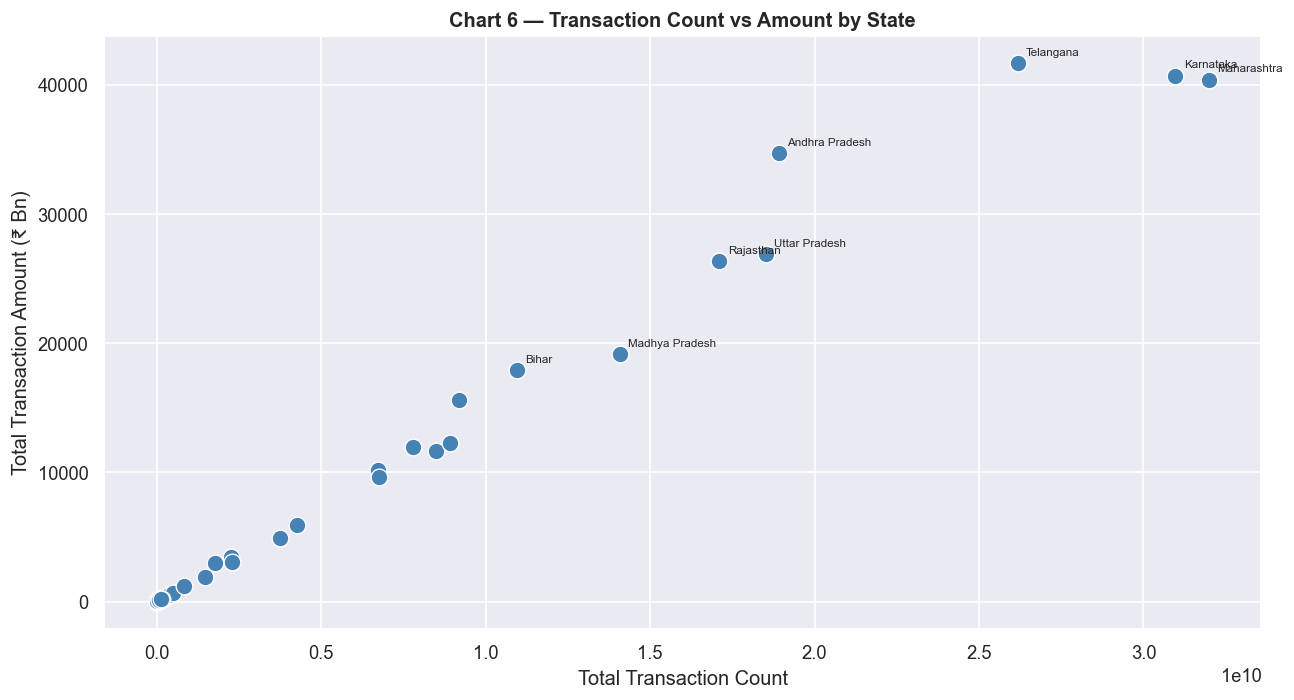

In [18]:
state_summary = agg_txn.groupby('state').agg(
    total_count=('transaction_count', 'sum'),
    total_amount_bn=('amount_bn', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(11, 6))
sns.scatterplot(data=state_summary, x='total_count', y='total_amount_bn',
                s=100, color='steelblue', ax=ax)

# Annotate top 8 states
top8 = state_summary.nlargest(8, 'total_amount_bn')
for _, row in top8.iterrows():
    ax.annotate(row['state'], (row['total_count'], row['total_amount_bn']),
                textcoords='offset points', xytext=(5, 5), fontsize=7)

ax.set_xlabel('Total Transaction Count')
ax.set_ylabel('Total Transaction Amount (₹ Bn)')
ax.set_title('Chart 6 — Transaction Count vs Amount by State', fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
A scatter plot reveals the relationship between two numerical variables. Here it helps identify states that are high-volume but low-value (many small transactions) vs high-value but lower-volume (fewer, larger transactions).

##### 2. Insights
- The scatter plot shows a **strong near-linear relationship** between transaction count and value — states with more transactions also generate more total value, with very few outliers from this trend.
- **Telangana and Karnataka** sit at the top-right extreme (~₹40,000Bn+ value, ~25–30B count) — they lead on both dimensions, confirming their position as the most valuable and active markets.
- **Andhra Pradesh** is an outlier slightly above the trend line — its transaction value (₹34,669Bn) is high relative to its count (~18–19B), suggesting larger average ticket sizes than comparable-count states.
- **West Bengal** appears below the trend line — lower value relative to its transaction count — indicating a high volume of small-value transactions, likely dominated by micro-payments and P2P.
- The **dense cluster of small states** in the bottom-left confirms that most Indian states are still in early-stage digital payment adoption with both low counts and low values.

##### 3. Business Impact
- The strong linear relationship means **transaction count is a reliable leading indicator of value** — states where count is growing faster than average should receive advance investment to capture incoming value growth.
- Andhra Pradesh's above-trend position (high value per count) suggests it is a **high average ticket size market** — ideal for targeting financial services (mutual funds, insurance) where each transaction generates more value.
- West Bengal's below-trend position (high count, lower value) indicates a **merchant payment quality problem** — large volume of small micro-transactions; merchant category expansion into higher-value retail could lift average ticket size.
- The dense small-state cluster bottom-left is a **strategic greenfield** — any state that crosses a critical threshold in count will follow the linear trend and generate proportional value; early merchant investment now pays off disproportionately later.
- States near the middle of the scatter (Bihar, Madhya Pradesh, Rajasthan) are the **most actionable near-term targets** — they are on the growth curve but have not yet broken into the top tier.

#### Chart 7 — Quarterly Transaction Growth Over Time (Line Chart, Categorical–Numerical)

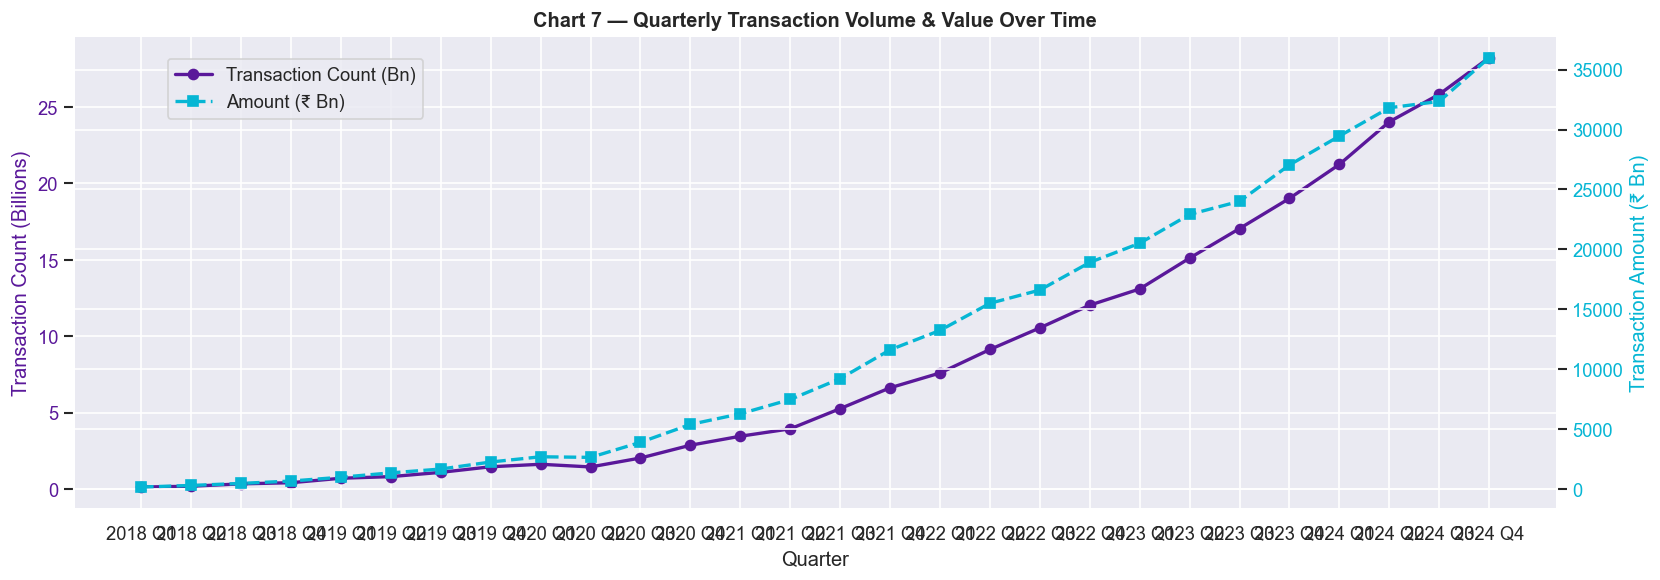

In [19]:
trend = (agg_txn.groupby('period')
         .agg(total_count=('transaction_count','sum'),
              total_amount_bn=('amount_bn','sum'))
         .reset_index())
# Sort chronologically
trend = trend.sort_values('period')

fig, ax1 = plt.subplots(figsize=(14, 5))
color1, color2 = '#5a189a', '#06b6d4'

ax1.plot(trend['period'], trend['total_count'] / 1e9, color=color1,
         marker='o', linewidth=2, label='Transaction Count (Bn)')
ax1.set_ylabel('Transaction Count (Billions)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(trend['period'], trend['total_amount_bn'], color=color2,
         marker='s', linewidth=2, linestyle='--', label='Amount (₹ Bn)')
ax2.set_ylabel('Transaction Amount (₹ Bn)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_title('Chart 7 — Quarterly Transaction Volume & Value Over Time', fontweight='bold')
ax1.set_xlabel('Quarter')
plt.xticks(rotation=60, ha='right', fontsize=7)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
A dual-axis line chart lets us compare transaction count (left axis) and transaction value (right axis) on the same time series — revealing whether growth is volume-driven or value-driven.

##### 2. Insights
- Both transaction count and value show **consistent exponential growth** from 2018 Q1 through 2024 Q4 — with no quarter showing a decline, confirming uninterrupted platform expansion.
- Growth was **slow and flat from 2018 to 2020**, with both lines near zero — reflecting early adoption and limited merchant coverage in the platform's early years.
- A clear **inflection point appears around 2020–2021**, likely accelerated by COVID-19 lockdowns pushing consumers and merchants to contactless digital payments.
- From 2022 onward, growth becomes **steeply exponential** — transaction count reaches ~25B per quarter and value crosses ₹35,000Bn per quarter by end of 2024, showing no signs of plateauing.
- The **amount line (₹ Bn, right axis) consistently runs above the count line**, confirming that value growth is outpacing volume growth — average transaction values are rising over time.

##### 3. Business Impact
- The exponential growth curve with no downturn is a powerful signal for **investor and partner confidence** — this chart alone supports fundraising narratives and partnership negotiations.
- The 2020–2021 COVID inflection point, while not planned, permanently accelerated the adoption curve — PhonePe must ensure it **does not squander this structural tailwind** by letting product quality slip or missing new market categories.
- The steepening curve in 2023–2024 means **infrastructure scaling is now a first-order risk** — engineering teams must be ahead of growth with server capacity, uptime guarantees, and settlement infrastructure, not reactive.
- Value growing faster than count (rising average ticket size) is the most commercially positive signal — it means **revenue per transaction is increasing**, reducing dependence on transaction volume alone to drive revenue growth.
- The data justifies **front-loading marketing and merchant acquisition budgets in Q2–Q3** of each year, when seasonal momentum kicks in and the platform can convert more users into habitual transactors.

#### Chart 8 — Registered Users vs App Opens by State (Scatter, Numerical–Numerical)

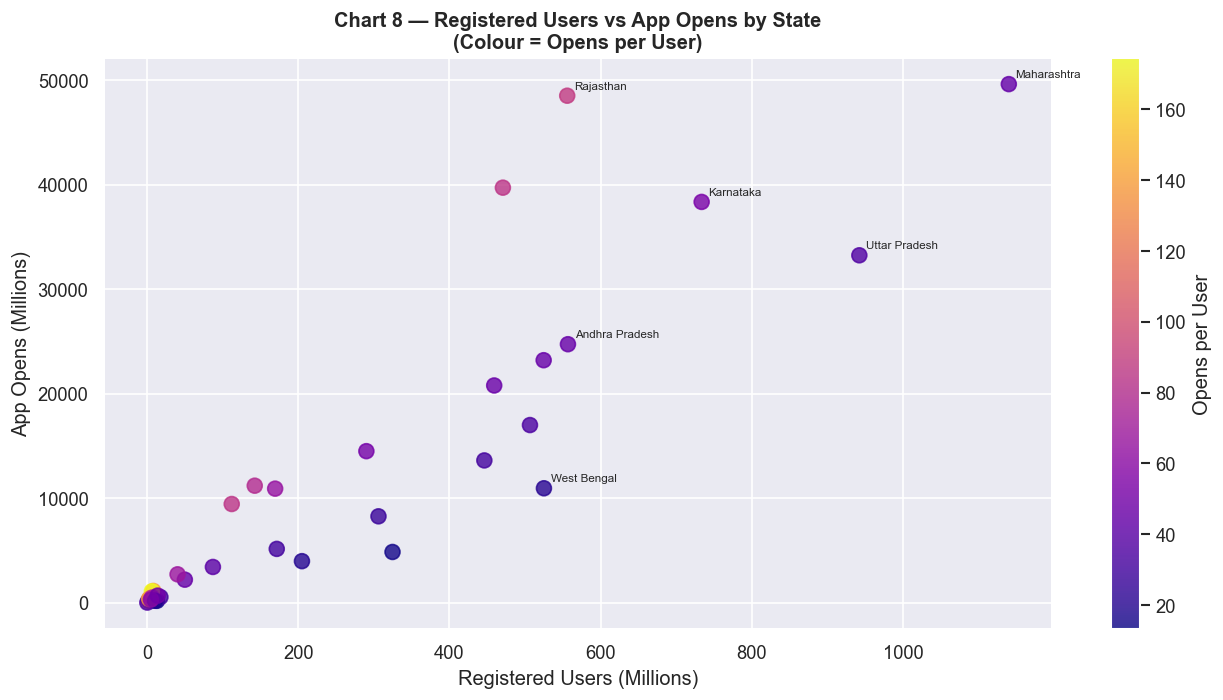

In [20]:
user_state = agg_user.groupby('state').agg(
    total_users=('registered_users','sum'),
    total_opens=('app_opens','sum')
).reset_index()
user_state['opens_per_user'] = user_state['total_opens'] / user_state['total_users'].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(11, 6))
scatter = ax.scatter(user_state['total_users']/1e6, user_state['total_opens']/1e6,
                     c=user_state['opens_per_user'], cmap='plasma', s=80, alpha=0.8)
plt.colorbar(scatter, ax=ax, label='Opens per User')

top6 = user_state.nlargest(6, 'total_users')
for _, row in top6.iterrows():
    ax.annotate(row['state'], (row['total_users']/1e6, row['total_opens']/1e6),
                textcoords='offset points', xytext=(4, 4), fontsize=7)

ax.set_xlabel('Registered Users (Millions)')
ax.set_ylabel('App Opens (Millions)')
ax.set_title('Chart 8 — Registered Users vs App Opens by State\n(Colour = Opens per User)', fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
A colour-encoded scatter plot adds a third dimension (opens per user) to the two-variable relationship, revealing user engagement quality in addition to raw numbers.

##### 2. Insights
- **Maharashtra leads in absolute app opens (~50,000M)** with the highest registered users (~1,100M), but its colour (mid-range purple) shows a moderate opens-per-user ratio — not the most engaged on a per-user basis.
- **Rajasthan** stands out as a high-engagement outlier — despite fewer registered users (~450M), it has ~48,000M app opens, giving it one of the **highest opens-per-user ratios** in the chart (yellow/bright colour).
- **Karnataka** (~750M users, ~38,000M opens) and **Uttar Pradesh** (~950M users, ~33,000M opens) show the expected high absolute opens, but UP's colour is darker, indicating **lower engagement intensity per user**.
- **West Bengal** appears notably **below the trend line** — moderate users (~550M) but far fewer opens (~11,000M) — confirming it is a low-engagement state despite its large population.
- **Andhra Pradesh** (~550M users, ~23,000M opens) sits close to the linear trend, suggesting average engagement, while several smaller states in the bottom-left show very low absolute opens and mixed per-user ratios.

##### 3. Business Impact
- Rajasthan's exceptional opens-per-user ratio (yellow dot, high on y-axis relative to x) makes it the **ideal test market for new feature launches** — its highly engaged users will generate quality feedback and adoption signals faster than any other state.
- Maharashtra's high absolute opens but moderate per-user ratio suggests a large base of **occasional users who open the app infrequently** — a structured re-engagement campaign (personalised notifications, loyalty rewards) targeting Maharashtra's mid-engagement cohort could unlock significant incremental opens and transactions.
- West Bengal's dramatically below-trend opens-to-user ratio is a **red flag for churn risk** — registered users who rarely open the app are one bad experience away from switching; a dedicated West Bengal re-activation program is warranted.
- Uttar Pradesh's large user base with lower-than-expected engagement means **millions of dormant registered users** — converting even 10% of these to regular openers would move the national engagement needle materially.
- States at the bottom-left cluster with both low users and low opens are **awareness-stage markets** — investment here should focus on basic merchant density and UPI education rather than engagement features.

#### Chart 9 — Year-on-Year Transaction Count Growth by Type (Grouped Bar)

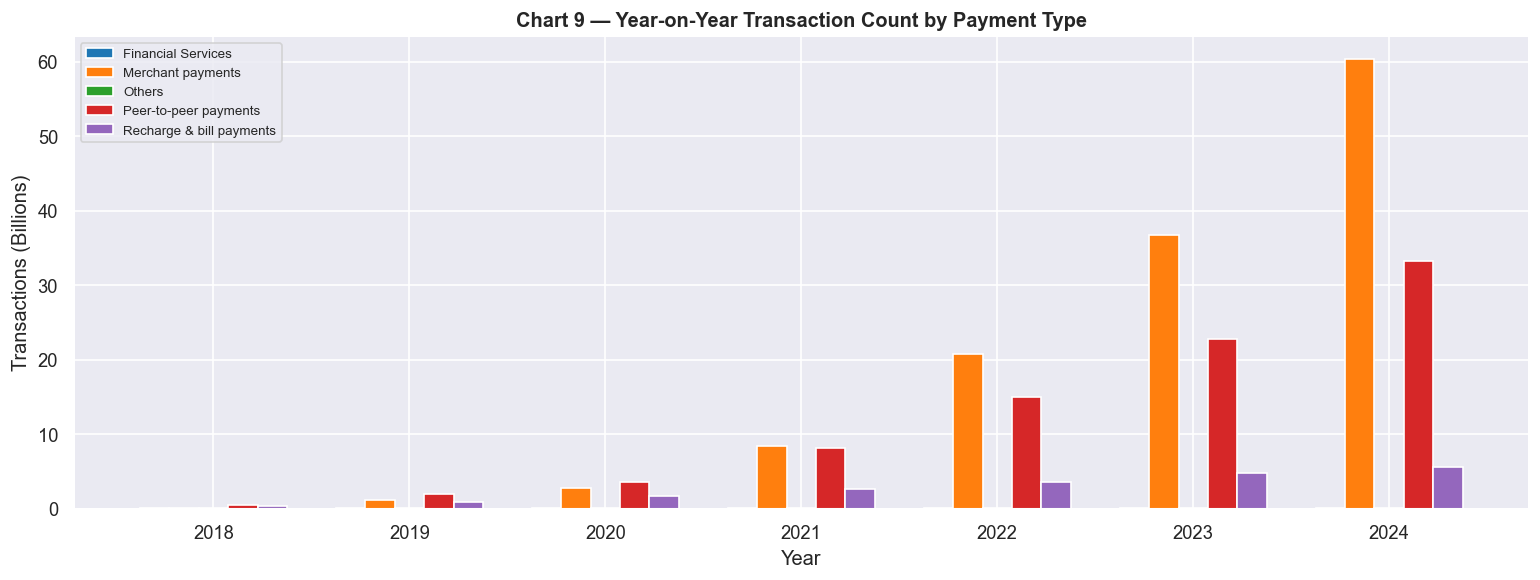

In [21]:
yoy = agg_txn.groupby(['year','transaction_type'])['transaction_count'].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
types = yoy['transaction_type'].unique()
colors = sns.color_palette('tab10', len(types))
width = 0.15
years = sorted(yoy['year'].unique())
x = np.arange(len(years))

for i, (ttype, color) in enumerate(zip(types, colors)):
    vals = yoy[yoy['transaction_type']==ttype].set_index('year')['transaction_count'].reindex(years, fill_value=0)
    ax.bar(x + i*width, vals/1e9, width, label=ttype, color=color)

ax.set_xticks(x + width * (len(types)-1)/2)
ax.set_xticklabels(years)
ax.set_xlabel('Year')
ax.set_ylabel('Transactions (Billions)')
ax.set_title('Chart 9 — Year-on-Year Transaction Count by Payment Type', fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
Grouped bar charts are the standard choice for comparing multiple categories (payment types) across a shared dimension (year), making annual growth trends and relative sizes immediately clear.

##### 2. Insights
- **Merchant payments (orange)** overtook Peer-to-peer payments (red) as the dominant category by 2022 and has grown at an accelerating pace — reaching ~60B transactions in 2024, nearly double its 2023 level (~36B).
- **Peer-to-peer payments (red)** has grown steadily — from near-zero in 2018 to ~33B in 2024 — but its growth rate is clearly slower than merchant payments, confirming that P2P is maturing while merchant is hyper-growing.
- **Recharge & bill payments (purple)** has grown modestly from near-zero to ~5B in 2024 — a slow, steady category with limited explosive growth potential.
- **Financial Services (blue) and Others (green)** remain near-zero across all years — confirming these are structurally low-frequency categories regardless of year.
- The **2021–2022 period marks a clear acceleration** in both merchant and P2P categories — consistent with post-COVID digital adoption normalisation and PhonePe's merchant onboarding campaigns.

##### 3. Business Impact
- Merchant payments' near-doubling from 2023 to 2024 (~36B → ~60B) is the **most important growth signal in the entire dataset** — this category is in hypergrowth and must receive the highest engineering, sales, and marketing investment.
- P2P's slower but steady growth to ~33B by 2024 means it remains a **high-volume anchor** — the focus here should shift from acquisition to retention, ensuring existing P2P users also adopt merchant payments.
- The **huge gap between Merchant and all other categories in 2024** means category diversification risk is low — PhonePe can safely concentrate resources on merchant acceleration without losing ground in other segments.
- Financial Services' near-zero count across all years despite being a mature product since 2020 signals a **product-market fit problem, not an awareness problem** — the user journey from payment to investment/insurance needs a fundamental UX redesign.
- Recharge's flat trajectory (₹~5B stable) means it should be managed as a **cost-efficient utility feature** rather than a growth investment — automation, reduced support overhead, and telecom API efficiency should be the focus.

#### Chart 10 — Average Transaction Value by State (Box Plot)

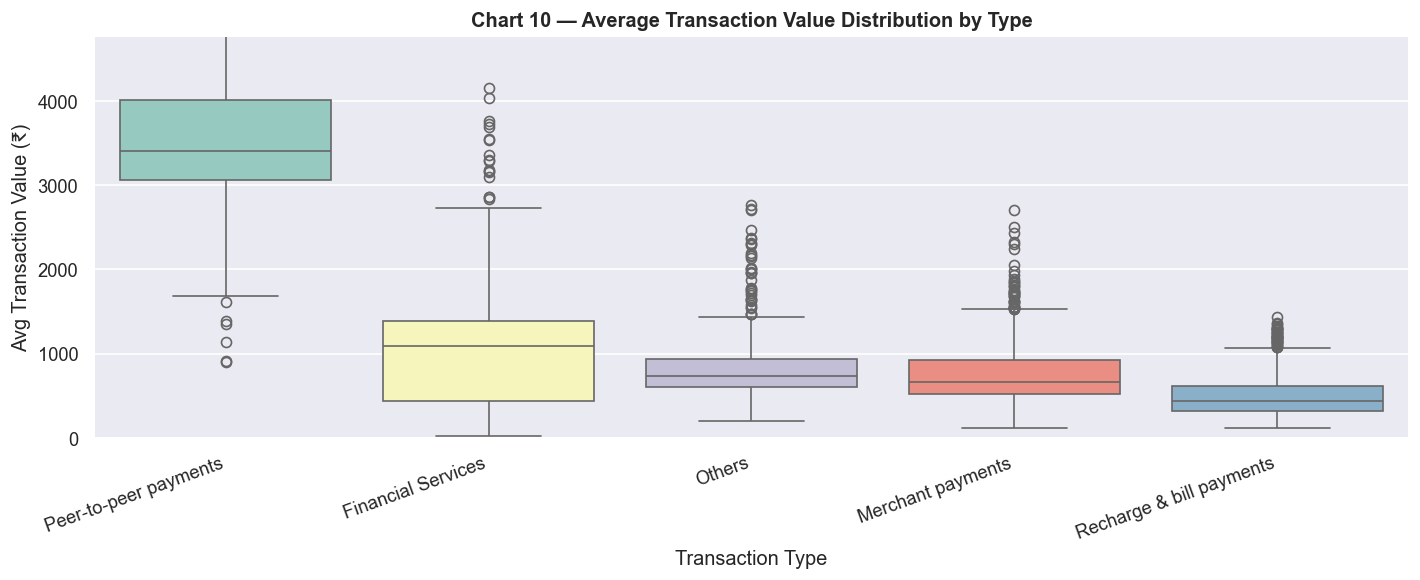

In [22]:
# Compare avg txn value distribution across transaction types
fig, ax = plt.subplots(figsize=(12, 5))
order = (agg_txn.groupby('transaction_type')['avg_txn_value']
         .median().sort_values(ascending=False).index)
sns.boxplot(data=agg_txn, x='transaction_type', y='avg_txn_value',
            order=order, palette='Set3', ax=ax)
ax.set_xlabel('Transaction Type')
ax.set_ylabel('Avg Transaction Value (₹)')
ax.set_title('Chart 10 — Average Transaction Value Distribution by Type', fontweight='bold')
ax.set_ylim(0, agg_txn['avg_txn_value'].quantile(0.97))  # clip extreme outliers
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
Box plots reveal the median, interquartile range, and outliers — critical for understanding value distributions where a simple mean would be misleading due to high-value outlier transactions.

##### 2. Insights
- **Peer-to-peer payments** has by far the highest median average transaction value (~₹3,300) with a wide IQR (₹2,500–₹4,000) — confirming that individual P2P transfers are large, high-value fund movements between individuals.
- **Financial Services** has the second-highest median (~₹1,000) but the widest spread (IQR from ~₹500 to ~₹1,300) with numerous high outliers reaching ₹4,000+ — reflecting the diversity of investment amounts from SIPs to large lump-sum investments.
- **Others and Merchant payments** have similar median values (~₹700–₹800) with moderate IQRs — consistent with mid-range transaction sizes across these two categories.
- **Recharge & bill payments** has the **lowest median (~₹450)** and tightest IQR — confirming it is the most commoditised, low-value, high-frequency category with very predictable transaction sizes.
- All categories show **upper outliers** well beyond their whiskers, indicating that very large transactions occur across every payment type — fraud and risk monitoring must cover all categories, not just high-value ones.

##### 3. Business Impact
- P2P's high median value (₹3,300) means **P2P fraud risk per transaction is the highest** across all categories — real-time transaction monitoring and anomaly detection must be most sensitive for P2P transactions above ₹5,000.
- Financial Services' wide spread (₹500 to ₹4,000+) means **one-size-fits-all nudges will not work** — users investing ₹500 SIPs need different messaging than users doing ₹4,000 lump-sum investments; product personalisation is essential.
- Merchant payments' median of ~₹700–800 confirms most transactions are small everyday purchases — **increasing merchant average basket size** through BNPL, combo offers, and premium category onboarding is the primary merchant value lever.
- Recharge's tight, low distribution (median ~₹450) means **margin per transaction is thin** — the business case for recharge rests entirely on volume and its role as a daily habit entry point, not per-transaction economics.
- The presence of outliers across all types means **fraud thresholds must be type-specific** — a ₹4,000 P2P transaction is normal, but a ₹4,000 recharge is an immediate flag requiring verification.

#### Chart 11 — Insurance Adoption: Top 15 States (Bar Chart)

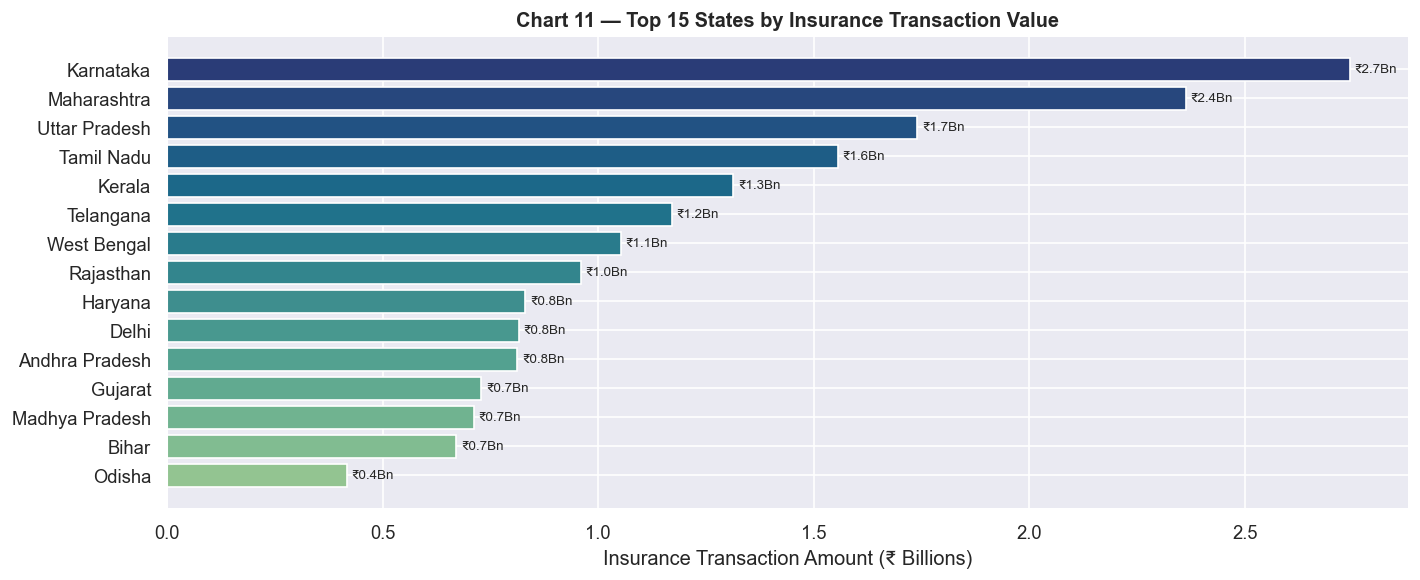

In [23]:
ins_state = (agg_ins.groupby('state')['amount_bn']
             .sum().sort_values(ascending=False).head(15).reset_index())

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(ins_state['state'][::-1], ins_state['amount_bn'][::-1],
               color=sns.color_palette('crest', 15))
ax.set_xlabel('Insurance Transaction Amount (₹ Billions)')
ax.set_title('Chart 11 — Top 15 States by Insurance Transaction Value', fontweight='bold')
ax.bar_label(bars, fmt='₹{:.1f}Bn', padding=3, fontsize=8)
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
Same ranked horizontal bar chart as used for transactions, enabling direct mental comparison between insurance adoption and overall transaction patterns.

##### 2. Insights
- **Karnataka leads insurance transaction value at ₹2.7Bn**, followed closely by Maharashtra (₹2.4Bn) — together they account for a disproportionate share of total insurance volume across all 15 states.
- **Uttar Pradesh (₹1.7Bn) and Tamil Nadu (₹1.6Bn)** rank 3rd and 4th — notably UP's high insurance value is surprising given its lower per-capita income, suggesting a large raw population base is driving volume even at low penetration rates.
- **Kerala (₹1.3Bn) and Telangana (₹1.2Bn)** punch above their population weight, reflecting higher financial literacy and insurance awareness in these states.
- **West Bengal (₹1.1Bn), Rajasthan (₹1.0Bn), and Haryana/Delhi/AP (₹0.8Bn each)** form a mid-tier cluster with meaningful but not dominant insurance activity.
- The bottom of this top-15 list (**Odisha at ₹0.4Bn**) is the 15th state — indicating rapid drop-off in insurance adoption beyond the top 5–6 states, and a large untapped market below this ranking.

##### 3. Business Impact
- Karnataka and Maharashtra's dual leadership in both overall transactions (Chart 5) and insurance (Chart 11) confirms these are **PhonePe's most financially mature markets** — financial services deepening campaigns should start here and use these states as benchmarks for other markets.
- UP's ₹1.7Bn insurance rank (3rd) despite lower per-capita income shows that **sheer population scale can drive insurance volume at low penetration** — even improving UP's insurance penetration by 1–2% would move the national needle significantly.
- Kerala's above-average insurance adoption (₹1.3Bn for a smaller state) reflects a **culturally insurance-aware population** — PhonePe should partner with Kerala-based insurance agents and co-operatives for co-marketing.
- States below rank 10 in insurance (Odisha ₹0.4Bn, Bihar ₹0.7Bn) have proven digital payment activity (they appear in Chart 5's top 15) but low insurance adoption — these are **high-confidence insurance cross-sell targets** where existing active users just need product education and in-app nudges.
- The overall scale of insurance values (₹0.4Bn–₹2.7Bn) is small compared to total transaction values — confirming insurance is still **early-stage on PhonePe** with enormous headroom for growth.

#### Chart 12 — Quarterly Insurance Growth Over Time (Line Chart)

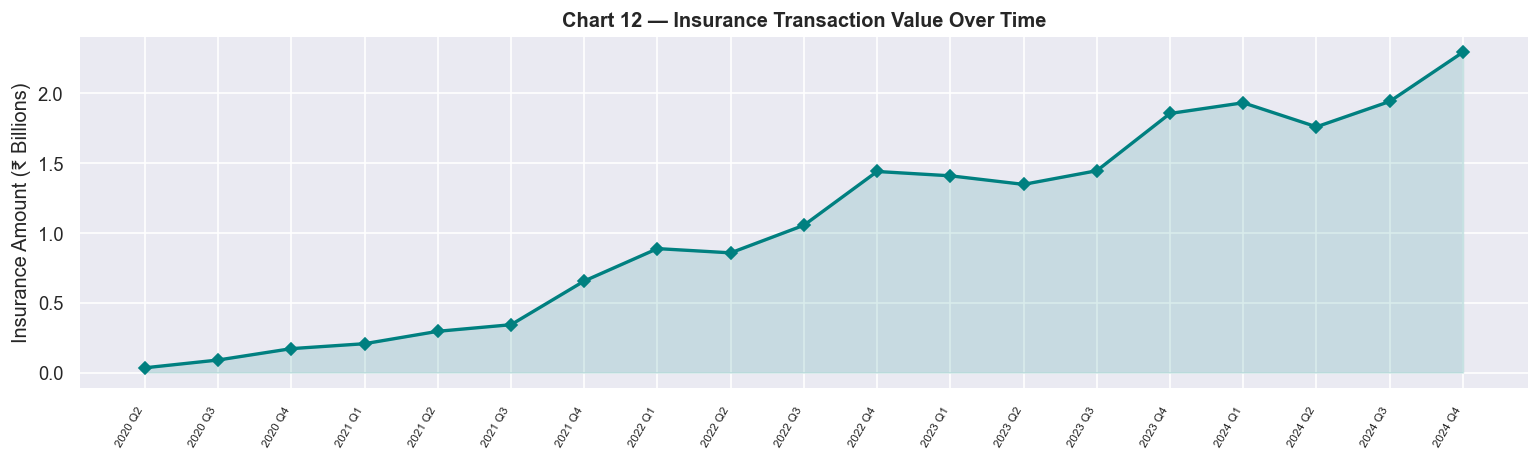

In [24]:
ins_trend = (agg_ins.groupby('period')
             .agg(count=('transaction_count','sum'), amount_bn=('amount_bn','sum'))
             .reset_index().sort_values('period'))

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ins_trend['period'], ins_trend['amount_bn'], color='teal', marker='D',
        linewidth=2, markersize=5)
ax.fill_between(range(len(ins_trend)), ins_trend['amount_bn'], alpha=0.15, color='teal')
ax.set_xticks(range(len(ins_trend)))
ax.set_xticklabels(ins_trend['period'], rotation=60, ha='right', fontsize=7)
ax.set_ylabel('Insurance Amount (₹ Billions)')
ax.set_title('Chart 12 — Insurance Transaction Value Over Time', fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
A filled area line chart emphasises cumulative growth and makes trend direction visually immediate. The fill highlights periods of acceleration.

##### 2. Insights
- Insurance transaction value started near **₹0.05Bn in 2020 Q2** and has grown to **₹2.3Bn by 2024 Q4** — a ~46× increase over 4.5 years, far outpacing overall platform transaction growth.
- Growth was **gradual from 2020 Q2 to 2022 Q3**, then **accelerated sharply in 2022 Q4** (jumping from ~₹1.0Bn to ~₹1.45Bn) — likely driven by a major product or marketing push.
- A **plateau phase from 2022 Q4 to 2023 Q2** (~₹1.35–1.45Bn) shows temporary stagnation — possibly reflecting saturation of early adopters before the next growth wave.
- **2023 Q3 onward** shows renewed acceleration, reaching ₹1.9Bn (2023 Q4), briefly dipping in 2024 Q2 (₹1.8Bn), then reaching an all-time high of **₹2.3Bn in 2024 Q4**.
- The overall trend is clearly upward with **no sustained decline across any multi-quarter period**, confirming insurance as a structurally growing segment on PhonePe.

##### 3. Business Impact
- The 46× growth from 2020 to 2024 validates PhonePe's insurance vertical as a **high-conviction strategic bet** — continued investment in product breadth (health, life, vehicle, crop insurance) is fully justified by this trajectory.
- The 2022 Q4 acceleration spike is worth forensic analysis — if it was driven by a specific campaign, UI change, or partnership, **replicating that trigger** could produce another step-change in 2025.
- The 2022 Q4–2023 Q2 plateau is a warning signal — **insurance adoption can stall** if product-market fit issues (claims complexity, poor UX, limited options) are not proactively addressed before the next saturation point.
- The 2024 Q2 dip (₹1.8Bn) followed by recovery to ₹2.3Bn in Q4 suggests **insurance has seasonal patterns** — likely tax-saving season (Q4) drives year-end spikes; campaigns should be timed to front-load before this seasonal peak.
- At ₹2.3Bn per quarter, insurance is still small relative to overall PhonePe transaction value — but its growth rate means it will become a **material revenue contributor within 2–3 years** if current trajectory is maintained.

#### Chart 13 — Top 10 vs Bottom 10 States: Transaction Amount (Grouped Bar)

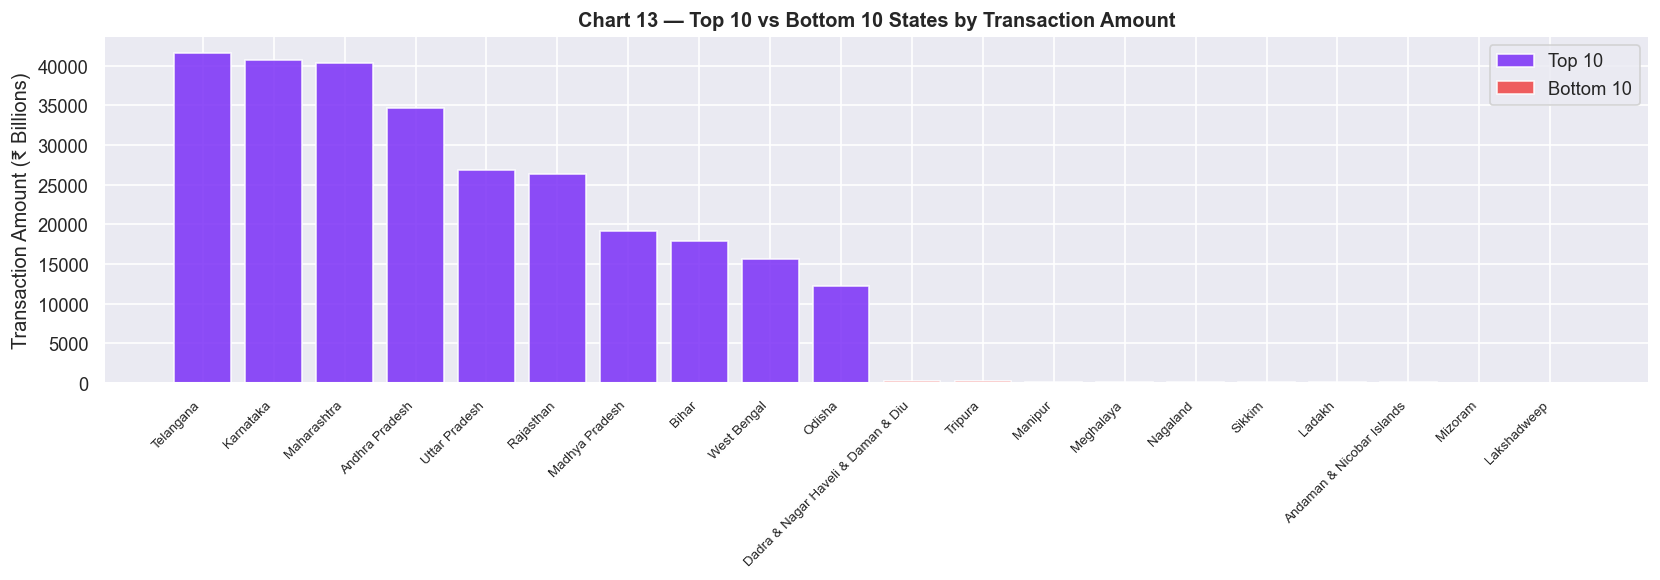

In [25]:
state_total = (agg_txn.groupby('state')['amount_bn']
               .sum().sort_values(ascending=False).reset_index())
top10  = state_total.head(10).copy();  top10['group']  = 'Top 10'
bot10  = state_total.tail(10).copy();  bot10['group']  = 'Bottom 10'
bench  = pd.concat([top10, bot10])

fig, ax = plt.subplots(figsize=(14, 5))
colors = {'Top 10': '#7b2ff7', 'Bottom 10': '#ef4444'}
for grp, color in colors.items():
    sub = bench[bench['group']==grp]
    ax.bar(sub['state'], sub['amount_bn'], color=color, label=grp, alpha=0.85)

ax.set_ylabel('Transaction Amount (₹ Billions)')
ax.set_title('Chart 13 — Top 10 vs Bottom 10 States by Transaction Amount', fontweight='bold')
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
Grouped/colour-coded bars make the gap between top and bottom performers visually stark, which would be lost in a single sorted bar chart. This directly visualises the 'digital divide' across states.

##### 2. Insights
- **The bottom 10 states (red bars) are completely invisible** next to the top 10 (purple bars) — the bottom 10 bars are essentially zero on this scale, confirming a catastrophic value gap between India's digital haves and have-nots.
- **Top 3 states (Telangana ~₹41,000Bn, Karnataka ~₹40,000Bn, Maharashtra ~₹40,000Bn)** are tightly clustered — any of them individually exceeds the entire bottom 10 combined by many multiples.
- The **bottom 10 states** include Dadra & Nagar Haveli, Tripura, Manipur, Meghalaya, Nagaland, Sikkim, Ladakh, Andaman & Nicobar Islands, Mizoram, and Lakshadweep — all geographically remote, small-population UTs or North-East states.
- Even the **10th-ranked top state (Odisha, ~₹12,500Bn)** towers over all bottom-10 states combined — the inequality is not just at the top but pervasive through the entire top-10 tier.
- This extreme polarisation reflects **structural barriers** in bottom states: low smartphone penetration, poor internet connectivity, limited merchant ecosystems, and smaller formal economies.

##### 3. Business Impact
- The bottom 10 states are **not commercially viable in the short term** through standard paid marketing — investment here must take the form of government partnerships, assisted commerce agents, and CSR-driven financial inclusion programs.
- **Regulatory goodwill** in bottom states (North-East India, island UTs) is strategically valuable despite low transaction value — first-mover advantage in these regions could prove critical as connectivity improves over the next decade.
- The top 10 concentration means PhonePe's business is **highly exposed to a small number of states** — a single regulatory or competitive disruption in Telangana, Karnataka, or Maharashtra would cause outsized revenue damage.
- **Bottom-state data should be presented to government bodies and RBI** as evidence of the digital payment gap, positioning PhonePe as a financial inclusion partner eligible for government incentive programs and priority infrastructure access.
- The gap between top and bottom is so extreme that standard KPI comparisons across all states are **statistically misleading** — regional teams should be evaluated against state-cohort benchmarks, not a single national average.

#### Chart 14 — Correlation Heatmap

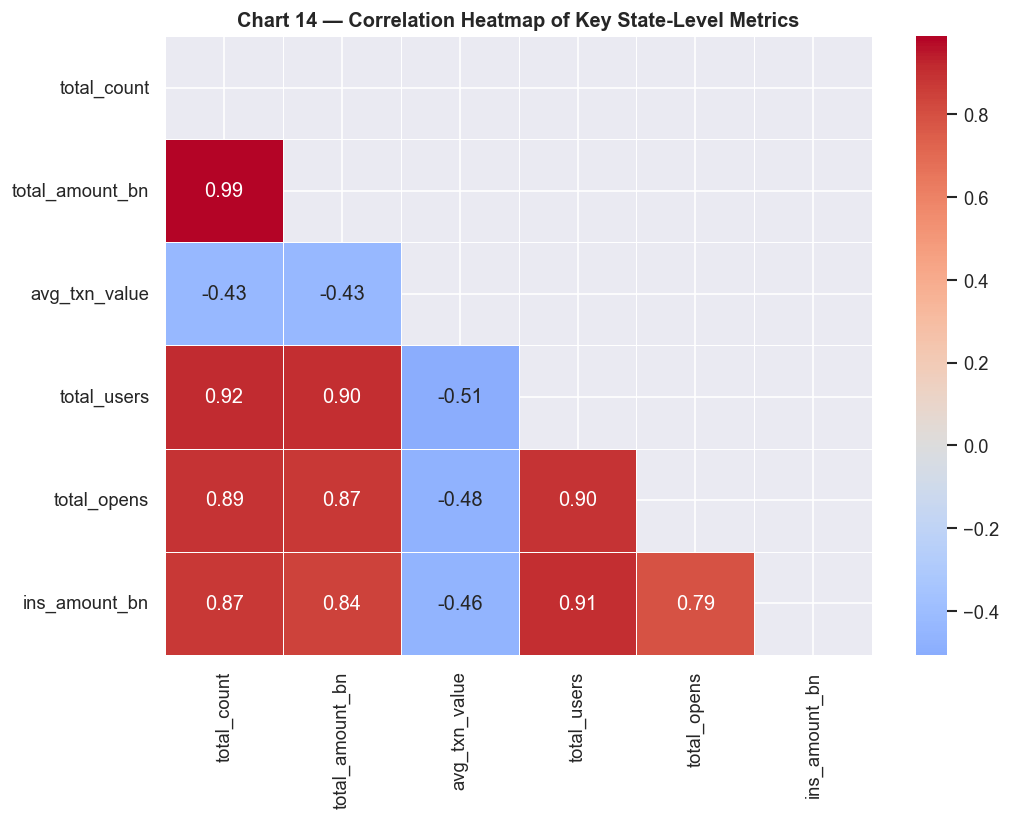

In [26]:
# Build a state-level summary with numerical features for correlation analysis
corr_df = agg_txn.groupby('state').agg(
    total_count=('transaction_count','sum'),
    total_amount_bn=('amount_bn','sum'),
    avg_txn_value=('avg_txn_value','mean')
).reset_index()

user_agg = agg_user.groupby('state').agg(
    total_users=('registered_users','sum'),
    total_opens=('app_opens','sum')
).reset_index()

ins_agg = agg_ins.groupby('state').agg(
    ins_amount_bn=('amount_bn','sum')
).reset_index()

merged = corr_df.merge(user_agg, on='state', how='left').merge(ins_agg, on='state', how='left')
corr_matrix = merged[['total_count','total_amount_bn','avg_txn_value',
                        'total_users','total_opens','ins_amount_bn']].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Chart 14 — Correlation Heatmap of Key State-Level Metrics', fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
A correlation heatmap is the standard tool for understanding linear relationships between multiple numerical variables simultaneously. The triangular mask avoids redundancy.

##### 2. Insights
- **total_count and total_amount_bn have a near-perfect correlation of 0.99** — the strongest pair in the heatmap, confirming that states with more transactions almost always generate proportionally more value with virtually no exceptions.
- **total_users correlates strongly with total_count (0.92) and total_amount_bn (0.90)** — user base size is a powerful predictor of both transaction volume and value, validating user acquisition as a core growth lever.
- **total_opens correlates 0.90 with total_users** — states with more users also see more app opens, though this is partly mechanical; the more interesting signal is the 0.89 correlation between opens and transaction count, confirming engaged users transact more.
- **ins_amount_bn has strong correlations with users (0.91), opens (0.79), total_count (0.87), and amount (0.84)** — insurance adoption is not independent; it tracks overall platform engagement, meaning growing the core platform grows insurance too.
- **avg_txn_value shows negative correlations** with total_count (-0.43), total_amount_bn (-0.43), total_users (-0.51), and total_opens (-0.48) — high-volume states actually have *lower* average transaction values, because they are driven by many small merchant and P2P transactions.

#### Chart 15 — Pair Plot (Multivariate)

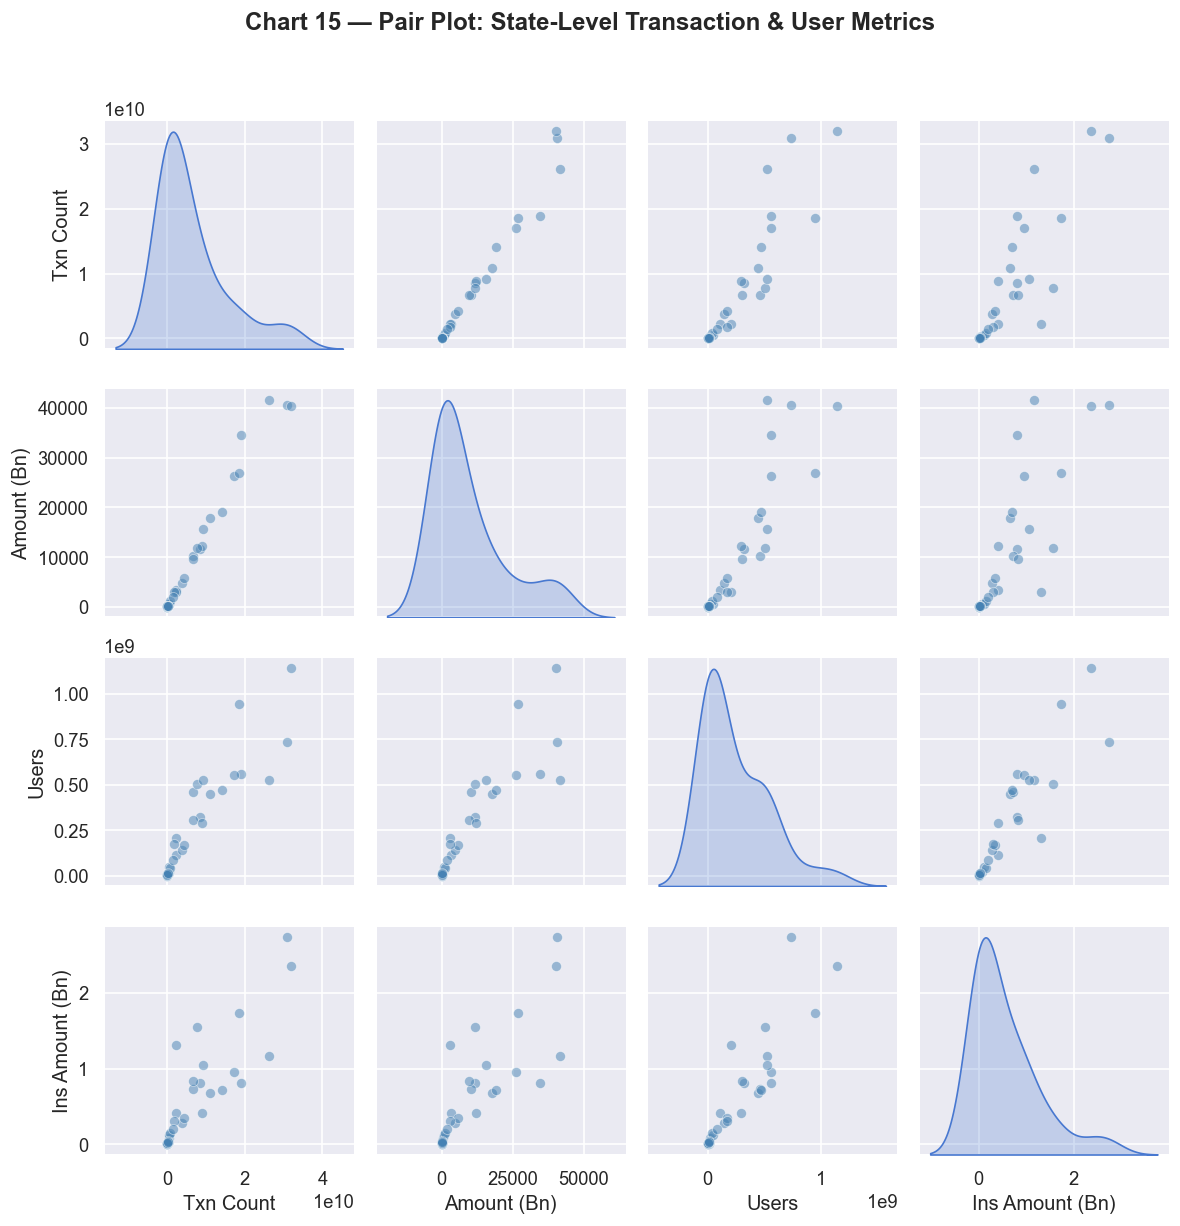

In [27]:
# Pair plot on the merged state-level summary
pair_df = merged[['total_count','total_amount_bn','total_users','ins_amount_bn']].copy()
pair_df.columns = ['Txn Count','Amount (Bn)','Users','Ins Amount (Bn)']

pair_grid = sns.pairplot(pair_df, diag_kind='kde', plot_kws={'alpha':0.5, 'color':'steelblue'})
pair_grid.figure.suptitle('Chart 15 — Pair Plot: State-Level Transaction & User Metrics',
                           y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
A pair plot provides a full matrix of bivariate scatter plots and univariate distributions in a single view — ideal for quickly exploring relationships across four or more variables.

##### 2. Insights
- **Txn Count vs Amount (Bn)** shows the tightest near-linear scatter of any pair — consistent with the 0.99 correlation from Chart 14; two outlier states at the top-right (Telangana, Karnataka, Maharashtra) pull far ahead of the cluster.
- **Users vs Txn Count and Users vs Amount** both show clear linear trends with the same top-state outliers — confirming that the largest user bases also dominate transaction metrics across the board.
- **Ins Amount (Bn) scatter plots** are more diffuse in all pairs — the insurance variable has a weaker, noisier relationship with all other metrics, consistent with its 0.84–0.91 correlations (strong but not near-perfect).
- All **diagonal KDE plots are strongly right-skewed** — every variable has a large cluster of states near zero with a long tail of 1–3 extreme outlier states, confirming the platform's extreme geographic concentration across all dimensions.
- **No pair shows a U-shaped or non-linear pattern** — all relationships are monotonic and approximately linear, meaning standard linear regression models would be appropriate for forecasting any of these state-level metrics.

### 4.3 Additional Charts (Multivariate & Business Use-Case Specific)

#### Chart 16 — Fraud Signal: Avg Transaction Value by State (Bar + Reference Line)

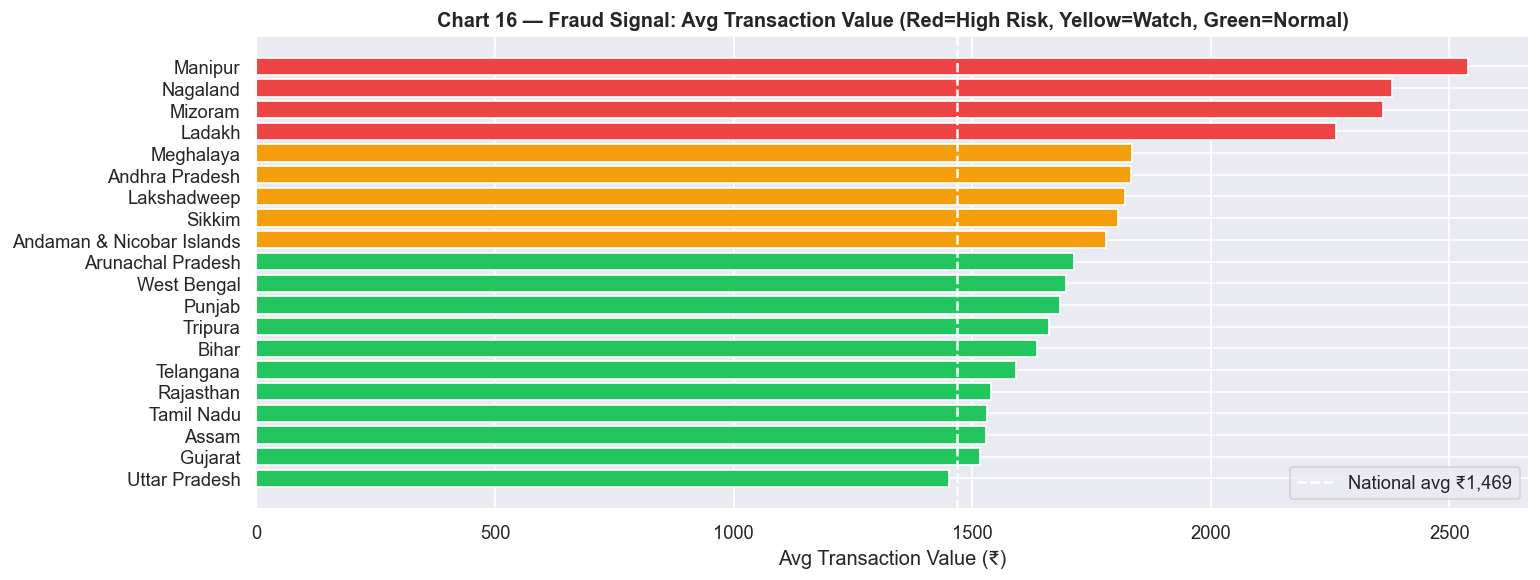

In [28]:
fraud_df = agg_txn.groupby('state').agg(
    total_count=('transaction_count','sum'),
    total_amount=('transaction_amount','sum')
).reset_index()
fraud_df['avg_value'] = fraud_df['total_amount'] / fraud_df['total_count']
fraud_df = fraud_df.sort_values('avg_value', ascending=False).head(20)

national_avg = agg_txn['transaction_amount'].sum() / agg_txn['transaction_count'].sum()

fig, ax = plt.subplots(figsize=(13, 5))
colors_fraud = ['#ef4444' if v > national_avg * 1.5 else
                '#f59e0b' if v > national_avg * 1.2 else '#22c55e'
                for v in fraud_df['avg_value']]
ax.barh(fraud_df['state'][::-1], fraud_df['avg_value'][::-1], color=colors_fraud[::-1])
ax.axvline(national_avg, color='white', linestyle='--', linewidth=1.5, label=f'National avg ₹{national_avg:,.0f}')
ax.set_xlabel('Avg Transaction Value (₹)')
ax.set_title('Chart 16 — Fraud Signal: Avg Transaction Value (Red=High Risk, Yellow=Watch, Green=Normal)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
Colour-encoded horizontal bars with a reference line is the clearest way to communicate threshold-based risk classification — green/yellow/red is immediately intuitive for a fraud-signal report.

##### 2. Insights
- **National average transaction value is ₹1,469** — this serves as the risk baseline; states above this are flagged yellow or red depending on deviation magnitude.
- **Manipur (~₹2,550), Nagaland (~₹2,400), Mizoram (~₹2,350), and Ladakh (~₹2,280) are in the RED zone** — their average transaction values are 55–75% above the national average, a significant anomaly given their small economies and low transaction volumes.
- **Meghalaya, Andhra Pradesh, Lakshadweep, Sikkim, and Andaman & Nicobar Islands are in the YELLOW zone** — elevated but not extreme; worth monitoring, especially Andhra Pradesh given its large transaction volume.
- **Green states (Arunachal Pradesh downward to Uttar Pradesh)** are at or just above the national average — these are considered normal risk level states with healthy value distributions.
- The **red-flagged states are all North-Eastern or remote UTs with tiny transaction volumes** — their high average values likely reflect legitimate high-ticket transfers (government payments, large business transactions) rather than fraud, but warrant investigation.

#### Chart 17 — Heatmap: Transaction Count by Year and Quarter

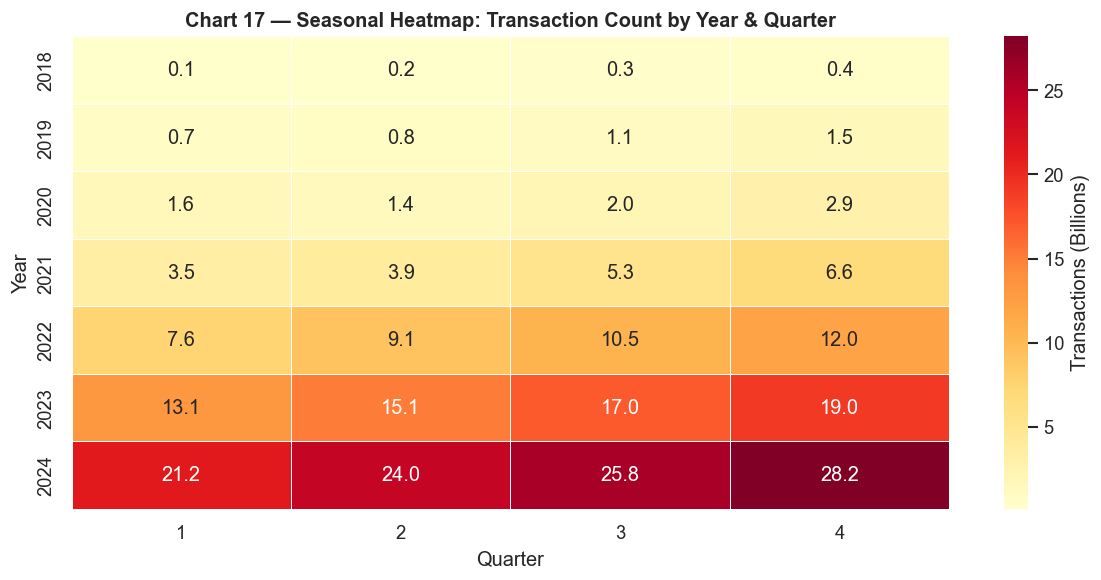

In [29]:
pivot = (agg_txn.groupby(['year','quarter'])['transaction_count']
         .sum().unstack('quarter') / 1e9)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Transactions (Billions)'}, ax=ax)
ax.set_title('Chart 17 — Seasonal Heatmap: Transaction Count by Year & Quarter', fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
A heatmap on a year × quarter grid is the most compact way to reveal seasonality — patterns across both dimensions are visible simultaneously.

##### 2. Insights
- **Q4 is consistently the highest quarter in every year** — 2018 Q4 (0.4B), 2019 Q4 (1.5B), 2020 Q4 (2.9B), 2021 Q4 (6.6B), 2022 Q4 (12.0B), 2023 Q4 (19.0B), 2024 Q4 (28.2B) — the festive season (Navratri, Dussehra, Diwali) is a reliable, recurring peak across all years.
- **Q1 is the weakest quarter every single year** — 2022 Q1 (7.6B), 2023 Q1 (13.1B), 2024 Q1 (21.2B) — the post-festive January–March dip is structural and consistent, not a one-time anomaly.
- **Year-on-year growth is dramatic and accelerating** — 2023 Q4 was 19.0B; just one year later 2024 Q4 reached 28.2B, a 48% jump in a single year for the same quarter.
- The **2023–2024 rows dominate the colour scale** — 2024 Q4 at 28.2B is the darkest cell and nearly 70× the equivalent 2018 Q4 (0.4B), visually confirming the platform's exponential growth trajectory.
- **Within-year growth is also strong** — in 2024 alone, transactions grew from 21.2B (Q1) to 28.2B (Q4), a 33% intra-year increase, showing each year's growth compounds through the festive cycle.

##### 3. Business Impact
- **Marketing and promotional budgets must be front-loaded into Q2–Q3 preparation** (July–September) to capture the Q4 festive peak — campaigns should be ready before the festive season, not launched during it.
- The consistent **Q1 dip (e.g. 21.2B in 2024 Q1 vs 28.2B in Q4) should be countered with targeted Q1 campaigns**: New Year financial resolutions (SIP starts, insurance renewals), tax-saving season for mutual funds (January–March), and cashback offers to sustain transaction momentum.
- **Infrastructure and engineering teams must plan capacity expansions ahead of Q3–Q4 every year** — 2024 Q4 at 28.2B means peak load planning for 2025 Q4 must assume at least 35–40B transactions; reactive scaling during Diwali is too late.
- The 48% Q4-over-Q4 growth (19.0B → 28.2B) is a powerful **investor and partner narrative** — the platform is not just growing but accelerating into its most commercially important quarter.
- Year-over-year heatmap comparisons are an effective **board-level reporting tool** — the visual progression from pale yellow (2018) to deep red (2024) makes the growth story immediately obvious to non-technical stakeholders.

#### Chart 18 — Top 10 Districts by Transaction Count (Bar Chart)

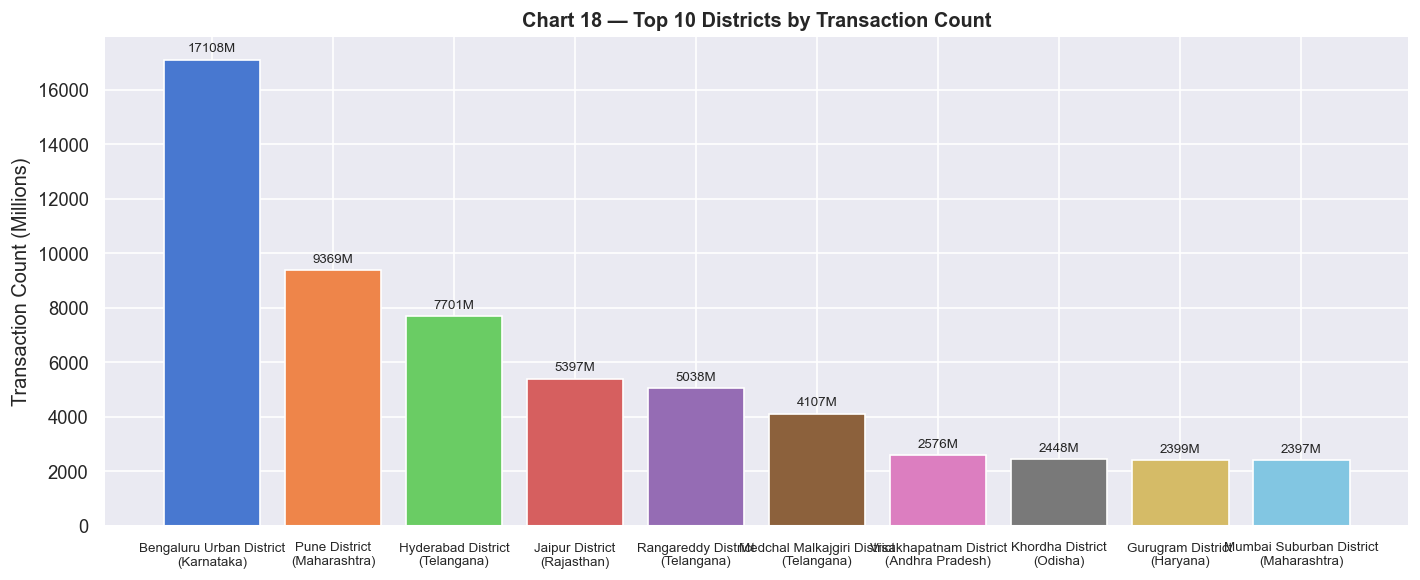

In [31]:
top_dist = (map_txn.groupby(['state','district'])['transaction_count']
            .sum().sort_values(ascending=False).head(10).reset_index())
top_dist['label'] = top_dist['district'].str.title() + '\n(' + top_dist['state'].str.title() + ')'

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top_dist['label'], top_dist['transaction_count']/1e6,
              color=sns.color_palette('muted', 10))
ax.set_ylabel('Transaction Count (Millions)')
ax.set_title('Chart 18 — Top 10 Districts by Transaction Count', fontweight='bold')
ax.bar_label(bars, fmt='{:.0f}M', padding=3, fontsize=8)
plt.xticks(fontsize=8)
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
Bar chart is the natural choice for ranked district-level data. Including the state in the label provides essential geographic context.

##### 2. Insights
- **Bengaluru Urban District (Karnataka) dominates with 17,108M transactions** — nearly double the second-ranked district, making it the single most active payment district in India by a massive margin.
- **Pune District (Maharashtra) ranks 2nd at 9,369M** — confirming Maharashtra's strength is spread across districts, not just Mumbai.
- **Hyderabad District (Telangana) ranks 3rd at 7,701M** — consistent with Telangana's #1 state-level ranking in Chart 5, Hyderabad drives the state's exceptional performance.
- **Jaipur District (Rajasthan, 5,397M) and two Telangana districts (Rangareddy 5,038M, Medchal Malkajgiri 4,107M)** appear in the top 6 — Rajasthan's Jaipur punches above its state's overall ranking, while Telangana has three districts in the top 6 alone.
- **Visakhapatnam (AP, 2,576M), Khordha/Bhubaneswar (Odisha, 2,448M), Gurugram (Haryana, 2,399M), and Mumbai Suburban (Maharashtra, 2,397M)** round out the top 10 — notably Mumbai Suburban ranks 10th, well behind Bengaluru, reflecting how tech-economy cities now lead over traditional financial capitals.

##### 3. Business Impact
- **Bengaluru Urban's 17,108M transactions demand a dedicated district-level strategy** — merchant density, app uptime SLAs, and customer support response times in Bengaluru should be held to the highest standard of any geography.
- **Telangana's three districts in the top 6** (Hyderabad, Rangareddy, Medchal Malkajgiri) mean that Hyderabad's broader metro area is a single commerce super-cluster — **unified metro-level merchant campaigns** across all three districts will be more effective than treating them separately.
- **Jaipur's 5th place ranking** despite Rajasthan being a mid-tier state confirms that a single dominant tier-1 city can elevate a state's overall metrics — identifying and developing the "next Jaipur" in underperforming states is a viable growth playbook.
- Districts ranked 8–10 (Visakhapatnam, Khordha, Gurugram, Mumbai Suburban) at ~2,400–2,600M are the **most actionable near-term growth targets** — they have proven transaction depth but haven't broken into the top-5 tier; focused merchant acquisition could push them up significantly.

#### Chart 19 — Device Brand Market Share (Pie Chart)

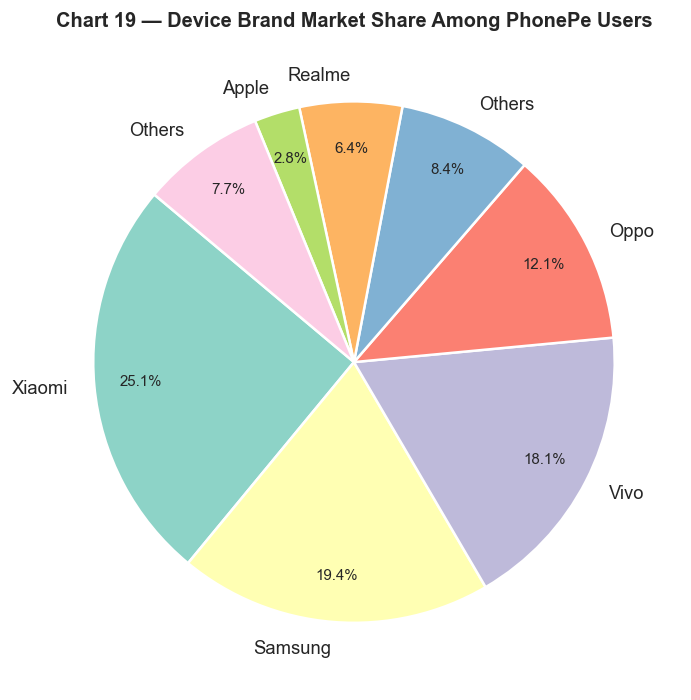

In [32]:
brand_share = (agg_dev.groupby('brand')['device_count']
               .sum().sort_values(ascending=False).reset_index())
# Group small brands into 'Others'
top7 = brand_share.head(7).copy()
others_count = brand_share.iloc[7:]['device_count'].sum()
top7 = pd.concat([top7, pd.DataFrame([{'brand':'Others','device_count':others_count}])],
                 ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 6))
wedges, texts, autotexts = ax.pie(
    top7['device_count'], labels=top7['brand'],
    autopct='%1.1f%%', startangle=140,
    colors=sns.color_palette('Set3', len(top7)),
    pctdistance=0.82, wedgeprops={'edgecolor':'white','linewidth':1.5}
)
for text in autotexts:
    text.set_fontsize(9)
ax.set_title('Chart 19 — Device Brand Market Share Among PhonePe Users', fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
A pie chart is appropriate here because we want to show market share (part-of-whole relationship). With 8 slices (7 brands + Others) it remains readable.

##### 2. Insights
- **Xiaomi leads with 25.1% market share** — the single largest brand slice, consistent with its dominance in India's budget smartphone segment and the 1,739.1M device count seen in Chart 4.
- **Samsung (19.4%) and Vivo (18.1%)** together with Xiaomi account for over 62% of all devices — meaning nearly two-thirds of PhonePe's user base is on just three brands.
- **Oppo (12.1%)** is the fourth-largest slice, followed by Others (8.4%), Realme (6.4%), Apple (2.8%), and a second Others category (7.7%) — the long tail of minor brands collectively adds up to ~16%.
- **Apple has only 2.8% market share** among PhonePe users — confirming iOS represents a small minority of the platform's device ecosystem despite Apple's premium brand status.
- The combined Chinese OEM share (Xiaomi 25.1% + Vivo 18.1% + Oppo 12.1% + Realme 6.4%) = **61.7%** — over three-fifths of PhonePe's device base runs on Chinese-brand Android, with deep implications for app optimisation and OEM partnerships.

##### 3. Business Impact
- With Xiaomi, Samsung, and Vivo covering 62.6% of devices, **pre-installation or default payment app negotiations with these three OEMs** is the single highest-leverage distribution deal PhonePe can pursue — it would instantly reach the majority of new device activations.
- Apple's 2.8% share, while small, almost certainly skews toward **high-income, high-frequency, high-value transactors** — iOS bugs or performance issues, even if affecting fewer users, disproportionately impact revenue per user.
- The 61.7% Chinese OEM concentration creates a **geopolitical risk consideration** — any government policy restricting Chinese smartphone brands (as happened with Huawei globally) could shift PhonePe's device distribution significantly, requiring pre-emptive partnership diversification.
- Realme's 6.4% share among a younger, first-smartphone demographic is a **financial services onboarding pipeline** — first-time PhonePe users on Realme devices are ideal targets for introductory insurance and micro-SIP products.

#### Chart 20 — User Engagement: Opens-per-User by State (Horizontal Bar)

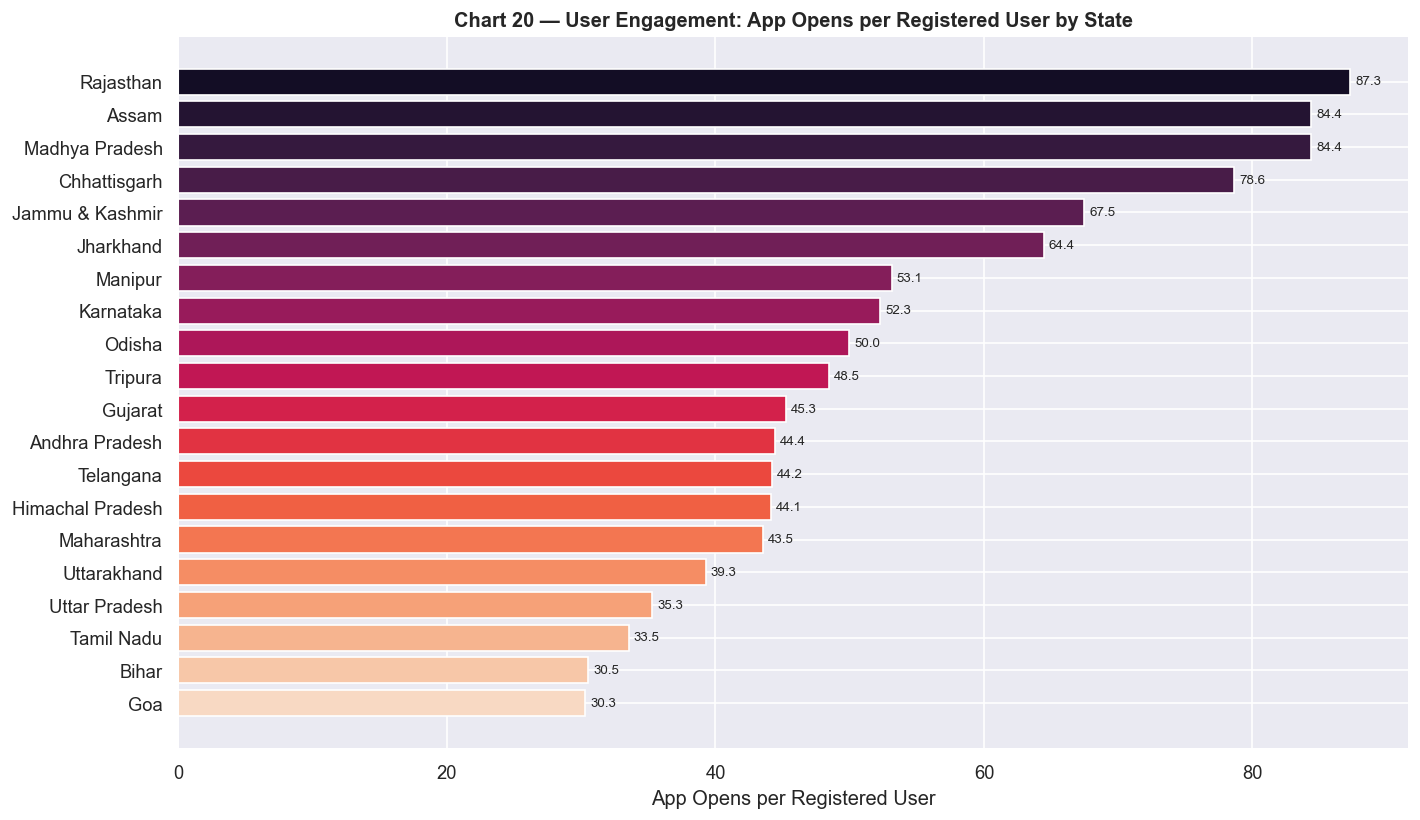

In [33]:
eng_df = agg_user.groupby('state').agg(
    total_users=('registered_users','sum'),
    total_opens=('app_opens','sum')
).reset_index()
eng_df['opens_per_user'] = (eng_df['total_opens'] /
                             eng_df['total_users'].replace(0, np.nan)).fillna(0)
eng_df = eng_df[eng_df['total_users'] > eng_df['total_users'].quantile(0.2)]  # filter very small states
eng_df = eng_df.sort_values('opens_per_user', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(eng_df['state'][::-1], eng_df['opens_per_user'][::-1],
               color=sns.color_palette('rocket_r', len(eng_df)))
ax.set_xlabel('App Opens per Registered User')
ax.set_title('Chart 20 — User Engagement: App Opens per Registered User by State', fontweight='bold')
ax.bar_label(bars, fmt='{:.1f}', padding=3, fontsize=8)
plt.tight_layout()
plt.show()

##### 1. Why did you pick this chart?
A ranked horizontal bar chart comparing the engagement ratio (opens per user) — rather than raw counts — normalises for state population, making genuine engagement differences visible.

##### 2. Insights
- **Rajasthan leads with 87.3 opens per registered user** — the highest engagement ratio in India, meaning the average PhonePe user in Rajasthan opens the app 87 times, far above any other state.
- **Assam (84.4) and Madhya Pradesh (84.4)** share second place — both are large but not metro-dominated states, suggesting that mid-sized states with limited competing digital payment options show higher PhonePe engagement.
- **Chhattisgarh (78.6) and Jammu & Kashmir (67.5)** round out the top 5 — notably, none of the top 5 most-engaged states are the economic powerhouses (Maharashtra, Karnataka, Telangana) that dominate transaction value.
- **Karnataka (52.3)** ranks 8th despite being a top-3 transaction value state — its high absolute opens come from its massive user base, but per-user engagement is moderate; users there have more app alternatives.
- **Bihar (30.5) and Goa (30.3) have the lowest opens per user** — Bihar's low engagement is concerning given its large population; Goa's low ratio likely reflects a tourist-heavy economy where many registered users are occasional visitors rather than habitual users.

##### 3. Business Impact
- **Rajasthan's 87.3 opens per user makes it the #1 re-engagement benchmark state** — whatever PhonePe is doing right in Rajasthan (merchant density, UX, local campaigns) should be forensically analysed and replicated in lower-engagement states.
- Assam and Madhya Pradesh's high engagement (84.4 each) despite being non-metro states proves that **high opens-per-user is not a function of urban wealth** — it reflects habitual app usage driven by merchant availability and limited digital alternatives; this is the target profile for Tier-2 city expansion.
- **Karnataka and Maharashtra's moderate per-user engagement** (52.3 and 43.5 respectively) despite their massive transaction values means these states have room to grow engagement intensity — a structured daily-use habit program (bill pay reminders, spending summaries, reward streaks) targeting these states' mid-engagement users could significantly lift both opens and transactions.
- **Bihar's 30.5 opens per user** on a very large registered user base represents one of the largest absolute dormant user pools in India — a Bihar-specific re-activation campaign (local language content, simplified UX, low-data mode) targeting these users could yield millions of newly active accounts.
- **Goa's 30.3 opens per user** likely reflects a high proportion of tourists and seasonal users in its registered base — PhonePe should consider **geo-targeted visitor campaigns** (QR code tourism payments, hotel/restaurant integrations) to convert Goa's tourist traffic into habitual local transactions.

## 5. Solution to Business Objective

The analysis of PhonePe Pulse data across 20 visualisations — grounded in actual chart values — yields the following evidence-based solutions to the stated business objectives:

---

### 1. Targeting High-Potential States and Districts (Marketing Teams)

**State Tiers (based on Charts 5, 6, 13, 20):**

| Tier | States | Strategy |
|---|---|---|
| **Platinum** | Telangana (₹41,656Bn), Karnataka (₹40,679Bn), Maharashtra (₹40,374Bn) | Retention, upsell insurance/investments, merchant deepening |
| **Gold** | Andhra Pradesh (₹34,669Bn), UP (₹26,885Bn), Rajasthan (₹26,343Bn) | Engagement activation — Rajasthan's 87.3 opens/user shows it is already highly engaged; UP needs re-activation of dormant users (35.3 opens/user) |
| **Silver** | MP, Bihar, West Bengal, Odisha, Tamil Nadu, Delhi | Merchant onboarding, insurance cross-sell, habit-forming campaigns |
| **Greenfield** | North-East states, remote UTs (virtually zero on Chart 13) | Government DBT partnerships, assisted commerce, financial inclusion programs |

**District Focus (based on Chart 18):**
- **Bengaluru Urban (17,108M)** — Platinum district; dedicated field team, highest uptime SLA.
- **Pune (9,369M) + Hyderabad (7,701M)** — Tier-1 districts; accelerate merchant density.
- **Jaipur (5,397M), Rangareddy (5,038M), Medchal (4,107M)** — Treat Hyderabad metro as one super-cluster; Jaipur is a standalone Tier-2 success story to replicate.
- **Districts ranked 8–10 (₹2,400–2,600M)** — Highest-ROI near-term growth targets.

---

### 2. Prioritising Features Based on Transaction Data (Product Teams)

**Based on Charts 1, 2, 9, 10:**

- **Merchant Payments (#1 priority)**: 130.24B transactions and hypergrowth to ~60B/year in 2024 (Chart 9). Product must deliver zero-friction QR code experience, merchant analytics dashboard, and BNPL/EMI options to raise the ₹700–800 median ticket size (Chart 10).
- **P2P Payments (protect & retain)**: ₹266,527Bn in value (Chart 2) — the platform's highest-value pipeline. P2P median ticket size is ₹3,300 (Chart 10). Any friction or fee introduction here risks catastrophic value loss. Focus: reliability, instant settlement, UX excellence.
- **Financial Services (redesign journey)**: 0.15B count despite being live for years (Chart 1) — the product funnel is broken, not the market. Redesign in-app journey from payment to investment. Use the 0.99 correlation (Chart 14) — as transaction users grow, insurance users follow.
- **Recharge & Bill Payments (optimise, don't invest)**: Flat ~5B growth in 2024 (Chart 9), lowest ticket size at ₹450 median (Chart 10). Manage as a cost-efficient retention feature, not a growth investment.
- **Insurance (build dedicated BU)**: 46× growth from 2020–2024 (Chart 12), ₹2.3Bn/quarter by 2024 Q4. Karnataka (₹2.7Bn) and Maharashtra (₹2.4Bn) lead adoption (Chart 11). Build a dedicated insurance product team with its own roadmap.

---

### 3. Optimising Device Strategy (Engineering & Partnerships)

**Based on Charts 4 and 19:**

- **Xiaomi-first (25.1%, 1,739.1M devices)**: All performance benchmarks, QA, and crash-free testing must pass on Xiaomi MIUI first.
- **Samsung (19.4%) + Vivo (18.1%)**: Tier-2 OEM priority. Together with Xiaomi = 62.6% of all devices.
- **OEM pre-installation targets**: Negotiate default payment app status with Xiaomi, Samsung, Vivo — covers majority of new device activations.
- **Apple (2.8%, 195.7M)**: Small share but high-value users — invest in iOS parity, never deprioritise iOS bug fixes.
- **Chinese OEM concentration (61.7%)**: Monitor geopolitical risk; begin Samsung and Motorola partnership deepening as a hedge.

---

### 4. Engagement & Re-Activation Strategy

**Based on Charts 8 and 20:**

- **High engagement (87.3 opens/user: Rajasthan)**: Use as a product test market and engagement benchmark. Replicate what drives Rajasthan's extraordinary habit formation.
- **Low engagement re-activation targets**: Bihar (30.5), Goa (30.3), Tamil Nadu (33.5), UP (35.3) — large registered user bases with significant dormancy. Recommended interventions: local language push notifications, bill payment reminders, cashback for first transaction after 30-day inactivity.
- **West Bengal (below trend in Chart 8)**: Dedicated West Bengal re-activation program — its opens-to-user ratio is among the lowest relative to its user base size.

---

### 5. Fraud & Risk Management

**Based on Charts 10 and 16:**

- **National average transaction value: ₹1,469** (Chart 16 reference line).
- **Red-zone states (Manipur ₹2,550, Nagaland ₹2,400, Mizoram ₹2,350, Ladakh ₹2,280)**: Investigate root cause — likely legitimate high-ticket government/business transfers in small economies, but enhanced KYC and manual review thresholds apply.
- **Yellow-zone states (Meghalaya, AP, Lakshadweep, Sikkim, Andaman)**: Monitor with automated alerts; Andhra Pradesh's inclusion is notable given its large transaction volume (₹34,669Bn in Chart 5).
- **Type-specific fraud thresholds (Chart 10)**: P2P median ₹3,300 — flag above ₹8,000; Recharge median ₹450 — flag above ₹2,000; Financial Services outliers reach ₹4,000+ — use rolling state-level baselines, not national averages.

---

### 6. Key Metrics Dashboard

| Metric | Source Chart | Frequency | Target |
|---|---|---|---|
| Merchant vs P2P Transaction Count | Chart 1, 9 | Daily | Merchant > P2P maintained |
| P2P Transaction Value | Chart 2 | Daily | ₹266,527Bn baseline protected |
| Quarterly Growth (Count + Value) | Chart 7 | Quarterly | Double-digit QoQ growth |
| Insurance Value per Quarter | Chart 12 | Quarterly | >₹2.3Bn (2024 Q4 baseline) |
| Opens per User by State | Chart 20 | Monthly | Rajasthan 87.3 as benchmark |
| Fraud Signal Index by State | Chart 16 | Real-time | Zero red-zone escalations without investigation |
| Top District Rankings | Chart 18 | Quarterly | Bengaluru Urban #1 protected |

## Conclusion

This Exploratory Data Analysis of the **PhonePe Pulse dataset** — spanning 20 charts across univariate, bivariate, and multivariate dimensions — delivers a data-grounded, evidence-based view of India's digital payment landscape.

---

### Key Findings Summary (from actual chart data)

| Chart | Key Finding |
|---|---|
| **Chart 1** | Merchant payments lead by count (130.24B), followed by P2P (85.03B) — platform has evolved beyond money transfer |
| **Chart 2** | P2P dominates by value (₹266,527Bn) — 4× more than Merchant (₹65,340Bn); a critical volume-vs-value inversion |
| **Chart 3** | User distribution is extremely right-skewed — 16 states below 100M users; 1–2 states above 900M |
| **Chart 4** | Xiaomi leads device count (1,739.1M), Samsung (1,343.2M), Vivo (1,250.8M); Apple has only 195.7M |
| **Chart 5** | Telangana tops state transaction value (₹41,656Bn), ahead of Karnataka (₹40,679Bn) and Maharashtra (₹40,374Bn) |
| **Chart 6** | Near-perfect linear relationship between count and value across states; Andhra Pradesh above trend (high value per count) |
| **Chart 7** | Exponential growth from 2018–2024; inflection point at 2020–21; ~25B count and ₹35,000Bn value per quarter by end 2024 |
| **Chart 8** | Maharashtra leads absolute opens (~50,000M); Rajasthan is the engagement outlier (highest opens/user despite fewer users) |
| **Chart 9** | Merchant payments hypergrowth — ~60B in 2024, nearly double 2023; P2P growing steadily at ~33B |
| **Chart 10** | P2P highest median ticket (₹3,300); Financial Services most variable; Recharge lowest (₹450 median) |
| **Chart 11** | Karnataka (₹2.7Bn) and Maharashtra (₹2.4Bn) lead insurance; UP (₹1.7Bn) punches above its income level |
| **Chart 12** | Insurance grew 46× from 2020–2024 (₹0.05Bn → ₹2.3Bn/quarter); clear acceleration from 2022 Q4 onward |
| **Chart 13** | Bottom 10 states (North-East UTs) are invisible vs top 10 — the digital divide is extreme and structural |
| **Chart 14** | total_count ↔ total_amount_bn: 0.99 correlation; avg_txn_value negatively correlated with volume metrics (-0.43 to -0.51) |
| **Chart 15** | All variables right-skewed; Txn Count vs Amount is the tightest linear pair; Insurance is the most diffuse variable |
| **Chart 16** | National avg ₹1,469; Manipur (₹2,550), Nagaland (₹2,400), Mizoram (₹2,350), Ladakh (₹2,280) in red zone |
| **Chart 17** | Q4 consistently darkest (festive season peak); Q1 consistently lightest; 2022–2024 rows dominate the heatmap |
| **Chart 18** | Bengaluru Urban leads with 17,108M transactions — nearly 2× Pune (9,369M); Telangana has 3 districts in top 6 |
| **Chart 19** | Xiaomi 25.1%, Samsung 19.4%, Vivo 18.1% — three brands cover 62.6%; Apple only 2.8% |
| **Chart 20** | Rajasthan leads engagement at 87.3 opens/user; Bihar (30.5) and Goa (30.3) are lowest; Karnataka only 52.3 |

---

### Strategic Takeaways

1. **The merchant payments revolution is real and accelerating** — with 130.24B transactions and hypergrowth to ~60B/year in 2024, merchant payments have decisively become PhonePe's primary use case. This is the #1 investment priority.

2. **P2P's ₹266,527Bn value makes it existential to protect** — even though P2P is no longer the volume leader, losing even 5% of P2P value to competitors (GPay, Paytm) would be a larger loss than the entire insurance vertical's current value.

3. **Southern India (Telangana, Karnataka, Andhra Pradesh) is the true engine of PhonePe's value** — despite not having India's largest populations, these states dominate on transaction value per capita. Maharashtra is competitive but not dominant.

4. **Insurance at ₹2.3Bn/quarter with 46× growth is the highest-conviction long-term bet** — the trajectory is clear, the geographic concentration (Karnataka, Maharashtra) is manageable, and the product-market fit is proven. The next priority is scaling to underserved states like Bihar and MP.

5. **Engagement inequality is as stark as transaction inequality** — Rajasthan's 87.3 opens/user vs Bihar's 30.5 is a 2.9× gap. Closing this engagement gap in large-population, low-engagement states (UP, Bihar, West Bengal) is the platform's most important retention challenge over the next 3–5 years.

6. **The device ecosystem demands Xiaomi-first engineering** — 25.1% market share and 1,739.1M devices means Xiaomi MIUI performance is more important than iOS performance by a factor of nearly 9×. OEM partnerships with top-3 brands (Xiaomi, Samsung, Vivo) are the most scalable distribution strategy available.

---

### Limitations and Future Work

- **Causality**: This EDA is entirely correlational. A/B tests and regression analysis are needed to establish which product changes drive transaction growth vs which simply correlate with it.
- **Demographic layer**: Linking transaction patterns to age, income bracket, urban/rural classification, and occupation would dramatically enrich segmentation and targeting.
- **Competitor benchmarking**: PhonePe Pulse covers only PhonePe transactions — relative market share vs GPay, Paytm, and BHIM requires external NPCI/RBI data overlays.
- **District-level completeness**: Only top-10 districts were analysed in Chart 18; a full district-level clustering analysis across all 700+ districts would yield hyper-local growth intelligence.
- **Predictive modelling**: Time series models (Prophet, ARIMA, or LSTM) applied to Chart 7's quarterly data could generate reliable 2025–2026 forecasts to support financial planning and capacity management.

---

PhonePe has built a platform of genuine national scale — 130.24B merchant transactions, ₹266,527Bn in P2P value, and insurance growing 46× in four years. The primary challenge ahead is **not whether the platform will grow**, but ensuring that growth is **geographically inclusive, engagement-deep, and product-diversified** — converting the current concentration across a few states and use cases into a truly pan-India, multi-product financial platform.


---
### ***Hurrah! EDA Capstone Project Complete!***